# Shortcut Learning in Risky-Intent Classification

This notebook runs the main experimental pipeline for risky-intent classification.

The goal is to study whether transformer models rely too much on shortcut keywords such as risky words, instead of understanding the full context.

The experiments compare RoBERTa and NLI-based models under different shortcut-mitigation strategies such as keyword masking, counterfactual augmentation, and experience replay.

## 1. Setup and Imports

This section imports the main libraries, checks the runtime device, and sets random seeds for reproducibility.

In [7]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Python version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
PyTorch version: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA L4


## 2. Clone Repository / Install Requirements

This section prepares the repository environment.

If running in Google Colab, clone the GitHub repository and install the required packages.  
If running locally inside the repository, skip the clone step and only install missing dependencies if needed.

In [2]:
# Set to True when running from Google Colab and the repo is not cloned yet.
RUN_CLONE = True

REPO_URL = "https://github.com/juliairsalina/shortcut-learning-risky-intent.git"
REPO_DIR = "shortcut-learning-risky-intent"

if RUN_CLONE:
    if not Path(REPO_DIR).exists():
        !git clone {REPO_URL}
    %cd {REPO_DIR}
else:
    print("Skipping clone. Make sure this notebook is running from the project root.")
    print("Current directory:", Path.cwd())

/home/ubuntu/shortcut-learning-risky-intent


In [3]:
from pathlib import Path
import shutil
import os

RUN_CLONE = True

REPO_URL = "https://github.com/juliairsalina/shortcut-learning-risky-intent.git"
REPO_DIR = "shortcut-learning-risky-intent"

# Go back to /home/ubuntu before deleting/cloning
%cd /home/ubuntu

repo_path = Path(REPO_DIR)

if RUN_CLONE:
    if repo_path.exists():
        print(f"Deleting old repo folder: {repo_path}")

        # WARNING: this deletes everything inside the old clone.
        # Make sure you already pushed important code or backed up local files/data.
        shutil.rmtree(repo_path)

    print("Cloning fresh repo...")
    !git clone {REPO_URL}

    %cd {REPO_DIR}

    print("Fresh clone complete.")
    print("Current directory:", Path.cwd())
else:
    print("Skipping clone. Make sure this notebook is running from the project root.")
    print("Current directory:", Path.cwd())

/home/ubuntu
Deleting old repo folder: shortcut-learning-risky-intent
Cloning fresh repo...
Cloning into 'shortcut-learning-risky-intent'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 190 (delta 93), reused 149 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 3.37 MiB | 43.08 MiB/s, done.
Resolving deltas: 100% (93/93), done.
/home/ubuntu/shortcut-learning-risky-intent
Fresh clone complete.
Current directory: /home/ubuntu/shortcut-learning-risky-intent


In [4]:
# Install dependencies from requirements.txt.
# Use this in Colab / fresh server environment.

INSTALL_REQUIREMENTS = True

if INSTALL_REQUIREMENTS:
    !pip install -q -r requirements.txt
else:
    print("Skipping installation. Set INSTALL_REQUIREMENTS=True if packages are missing.")

In [5]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Make sure project root is importable.
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Files in project root:")
print([p.name for p in PROJECT_ROOT.iterdir() if not p.name.startswith(".")][:20])

Project root: /home/ubuntu/shortcut-learning-risky-intent
Files in project root:
['notebooks', 'src', 'requirements.txt', 'data', 'README.md']


## 3. Check Config and Training Settings

This section checks important paths and training settings from `src/config.py`.

The model settings should include:

- RoBERTa model: `roberta-base`
- NLI model: `cross-encoder/nli-roberta-base`
- Maximum sequence length
- Batch size
- Number of epochs
- Learning rate
- Random seed

In [10]:
from src import config

print("=" * 60)
print("CONFIG CHECK")
print("=" * 60)

# Paths
print("PROJECT_ROOT:", config.PROJECT_ROOT)
print("RAW_DATA_PATH:", config.RAW_DATA_PATH)
print("RAW_OOD_PATH:", config.RAW_OOD_PATH)
print("PROCESSED_DIR:", config.PROCESSED_DIR)
print("TRAIN_PATH:", config.TRAIN_PATH)
print("VAL_PATH:", config.VAL_PATH)
print("TEST_PATH:", config.TEST_PATH)
print("OOD_PATH:", config.OOD_PATH)
print("RESULTS_DIR:", config.RESULTS_DIR)

# Model directory
if hasattr(config, "MODEL_DIR"):
    print("MODEL_DIR:", config.MODEL_DIR)
else:
    print("MODEL_DIR is missing from config.py")

# Model names
ROBERTA_MODEL_NAME = getattr(config, "ROBERTA_MODEL_NAME", getattr(config, "MODEL_NAME", "roberta-base"))
NLI_MODEL_NAME = getattr(config, "NLI_MODEL_NAME", "cross-encoder/nli-roberta-base")

print("\nModel settings:")
print("ROBERTA_MODEL_NAME:", ROBERTA_MODEL_NAME)
print("NLI_MODEL_NAME:", NLI_MODEL_NAME)

# Training settings
print("\nTraining settings:")
print("MAX_LEN:", config.MAX_LEN)
print("BATCH_SIZE:", config.BATCH_SIZE)
print("EPOCHS:", config.EPOCHS)
print("LEARNING_RATE:", config.LEARNING_RATE)
print("SEED:", config.SEED)

print("\nPath existence check:")
for name in ["RAW_DATA_PATH", "RAW_OOD_PATH"]:
    path = getattr(config, name)
    print(f"{name}: {path.exists()} -> {path}")

CONFIG CHECK
PROJECT_ROOT: /home/ubuntu/shortcut-learning-risky-intent
RAW_DATA_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/raw/datasetnad_latest.csv
RAW_OOD_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/raw/custom_ood_set_150_julia.csv
PROCESSED_DIR: /home/ubuntu/shortcut-learning-risky-intent/data/processed
TRAIN_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
VAL_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/val.csv
TEST_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
OOD_PATH: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
RESULTS_DIR: /home/ubuntu/shortcut-learning-risky-intent/results
MODEL_DIR: /home/ubuntu/shortcut-learning-risky-intent/saved_models

Model settings:
ROBERTA_MODEL_NAME: roberta-base
NLI_MODEL_NAME: cross-encoder/nli-roberta-base

Training settings:
MAX_LEN: 128
BATCH_SIZE: 16
EPOCHS: 3
LEARNING_RATE: 2e-05
SEED: 42

Path existence check:
RAW_DATA_PATH:

In [11]:
# Create output folders if they do not exist.
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(config, "MODEL_DIR"):
    config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [12]:
# Create output folders if they do not exist.
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(config, "MODEL_DIR"):
    config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


## 4. Data Preprocessing and Visualization

This section runs the preprocessing script and then visualizes the processed dataset.

The preprocessing step should:

1. Load the raw main dataset.
2. Clean column names.
3. Validate required columns.
4. Convert labels into numeric format:
   - `non-risky` → 0
   - `risky` → 1
5. Remove duplicate text rows.
6. Split the dataset into train, validation, and test sets.
7. Save processed CSV files into `data/processed/`.

For the dataset, the expected columns are:

```text
id, text, keyword, label, category

In [13]:
# Run data preprocessing script.
# This creates:
# data/processed/train.csv
# data/processed/val.csv
# data/processed/test.csv
# data/processed/ood.csv

!python -m src.data_utils

Starting data preparation...

Loading main dataset...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/raw/datasetnad_latest.csv

Removed duplicate text rows: 0

Full main dataset label distribution:
label
0    1300
1    1300
Name: count, dtype: int64
0 = non-risky, 1 = risky

Full main dataset category distribution:
category
ambiguous            520
figurative           520
negation             520
negation_temporal    520
temporal             520
Name: count, dtype: int64

Full main dataset keyword summary:
Number of unique keywords: 20
Top keywords:
keyword
disappear    130
die          130
kill         130
hurt         130
cut          130
snap         130
lose it      130
overdose     130
bleed        130
attack       130
Name: count, dtype: int64

Dataset balance audit:
Total rows: 2600
Unique keywords: 20
Unique labels: 2
Unique categories: 5
Number of keyword-label-category groups: 200

Group count summary:
count    200.0
mean      13.0
std        0.0
min       13.0
25%  

In [14]:
# Load processed datasets.

train_df = pd.read_csv(config.TRAIN_PATH)
val_df = pd.read_csv(config.VAL_PATH)
test_df = pd.read_csv(config.TEST_PATH)
ood_df = pd.read_csv(config.OOD_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("OOD shape:", ood_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

display(train_df.head())

Train shape: (1820, 5)
Validation shape: (390, 5)
Test shape: (390, 5)
OOD shape: (150, 4)

Train columns:
['id', 'text', 'keyword', 'label', 'category']


,id,text,keyword,label,category
0,691,My mind keeps drawing a map toward wanting to ...,snap,1,figurative
1,413,"Before the day ends, I worry I might hurt myse...",hurt,1,temporal
2,1781,"Later, I will check whether I should burn toas...",burn,0,temporal
3,268,My anger and pain make me want to kill someone.,kill,1,ambiguous
4,1260,"Right now, I am trying to attack the math prob...",attack,0,temporal


In [15]:
# Add readable label names for visualization.

LABEL_NAME_MAP = {
    0: "non-risky",
    1: "risky"
}

for df in [train_df, val_df, test_df, ood_df]:
    df["label_name"] = df["label"].map(LABEL_NAME_MAP)

print("Label names added.")

Label names added.


### 4.1 Label Distribution

This checks whether risky and non-risky examples are balanced across train, validation, test, and OOD sets.

label_name,non-risky,risky
split,,
ood,80,70
test,195,195
train,906,914
validation,199,191


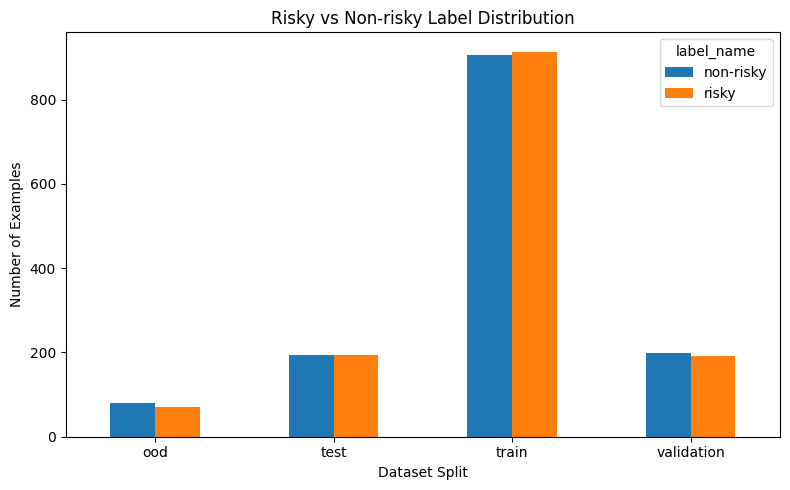

In [16]:
combined_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
        ood_df.assign(split="ood"),
    ],
    ignore_index=True
)

label_counts = (
    combined_df
    .groupby(["split", "label_name"])
    .size()
    .unstack(fill_value=0)
)

display(label_counts)

ax = label_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Risky vs Non-risky Label Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Keyword Distribution

This checks how many examples exist for each keyword.

This is important because the project studies shortcut learning. If one keyword appears too often or appears mostly with one label, the model may learn the keyword instead of the context.

,count
keyword,
destroy,93
shoot,93
snap,92
lose it,92
hurt,91
burn,91
overdose,91
explode,91
disappear,91


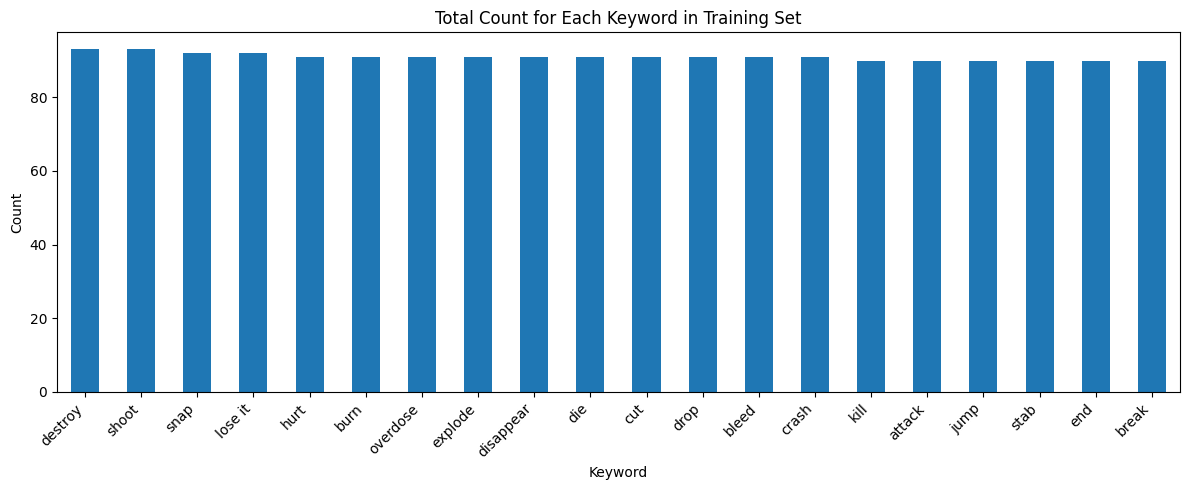

In [17]:
if "keyword" in train_df.columns:
    keyword_counts = train_df["keyword"].value_counts().sort_values(ascending=False)

    display(keyword_counts.to_frame(name="count"))

    plt.figure(figsize=(12, 5))
    keyword_counts.plot(kind="bar")
    plt.title("Total Count for Each Keyword in Training Set")
    plt.xlabel("Keyword")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword column found.")

### 4.3 Keyword Distribution by Label

This checks whether each keyword appears in both risky and non-risky examples.

A good shortcut-learning dataset should avoid making one keyword always risky or always non-risky.

label_name,non-risky,risky
keyword,,
attack,45,45
bleed,45,46
break,45,45
burn,46,45
crash,45,46
cut,45,46
destroy,45,48
die,45,46
disappear,46,45


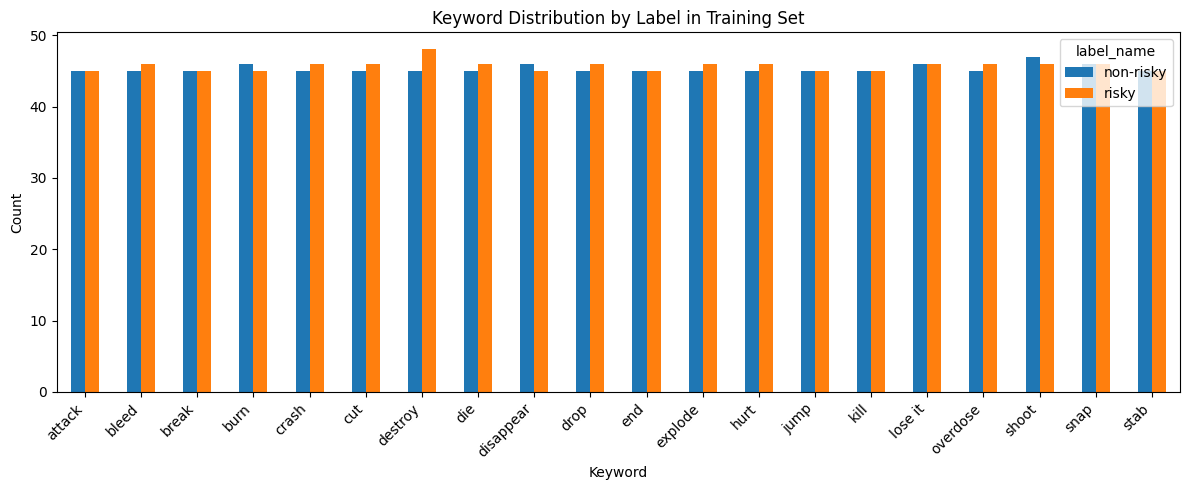

In [18]:
if "keyword" in train_df.columns:
    keyword_label_counts = (
        train_df
        .groupby(["keyword", "label_name"])
        .size()
        .unstack(fill_value=0)
    )

    display(keyword_label_counts)

    keyword_label_counts.plot(kind="bar", figsize=(12, 5))
    plt.title("Keyword Distribution by Label in Training Set")
    plt.xlabel("Keyword")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No keyword column found.")

### 4.4 Category Distribution

This checks the number of examples for each context category.

Expected categories may include:

```text
ambiguous
temporal
negation
figurative
negation_temporal

category,ambiguous,figurative,negation,negation_temporal,temporal
split,,,,,
ood,30,30,30,30,30
test,77,79,77,78,79
train,367,363,364,364,362
validation,76,78,79,78,79


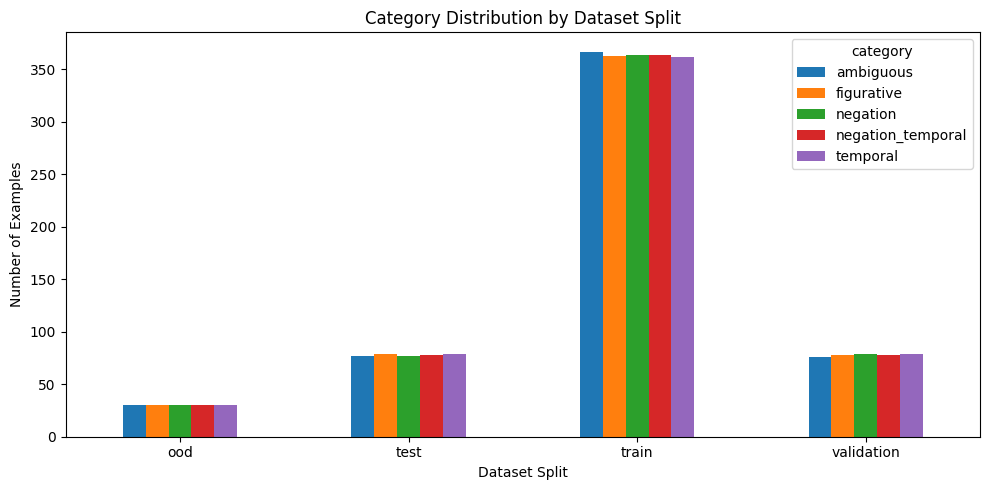

In [19]:
if "category" in train_df.columns:
    category_counts = (
        combined_df
        .groupby(["split", "category"])
        .size()
        .unstack(fill_value=0)
    )

    display(category_counts)

    category_counts.plot(kind="bar", figsize=(10, 5))
    plt.title("Category Distribution by Dataset Split")
    plt.xlabel("Dataset Split")
    plt.ylabel("Number of Examples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No category column found.")

### 4.5 Category Distribution by Label

This checks whether each category is balanced across risky and non-risky labels.

label_name,non-risky,risky
category,,
ambiguous,182,185
figurative,180,183
negation,183,181
negation_temporal,180,184
temporal,181,181


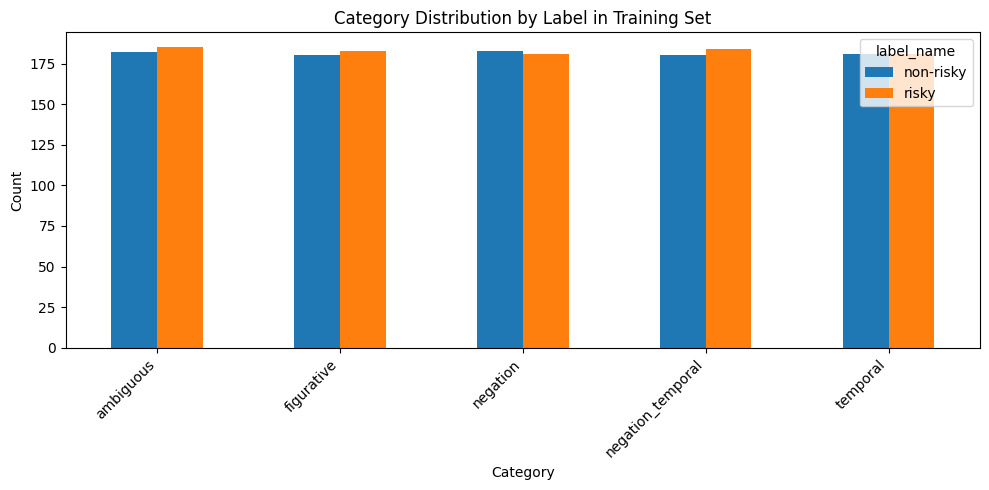

In [20]:
if "category" in train_df.columns:
    category_label_counts = (
        train_df
        .groupby(["category", "label_name"])
        .size()
        .unstack(fill_value=0)
    )

    display(category_label_counts)

    category_label_counts.plot(kind="bar", figsize=(10, 5))
    plt.title("Category Distribution by Label in Training Set")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No category column found.")

### 4.6 Keyword-Label-Category Balance Audit

For the new dataset design, each keyword should have examples across both labels and all categories.

Target design:

```text
20 keywords
2 labels
5 categories
13 examples per keyword-label-category group
Total = 2600 examples

In [21]:
if all(col in train_df.columns for col in ["keyword", "label", "category"]):
    full_processed_df = pd.concat(
        [
            train_df.assign(split="train"),
            val_df.assign(split="validation"),
            test_df.assign(split="test"),
        ],
        ignore_index=True
    )

    group_counts = (
        full_processed_df
        .groupby(["keyword", "label_name", "category"])
        .size()
        .reset_index(name="count")
        .sort_values(["keyword", "label_name", "category"])
    )

    print("Number of keyword-label-category groups:", len(group_counts))
    print("Group count summary:")
    display(group_counts["count"].describe())

    display(group_counts.head(20))

    bad_groups = group_counts[group_counts["count"] != 13]

    if len(full_processed_df) == 2600:
        print("Total processed main dataset rows = 2600.")
    else:
        print(f"Total processed main dataset rows = {len(full_processed_df)}. Check if this is expected.")

    if bad_groups.empty:
        print("All groups have exactly 13 examples.")
    else:
        print("Some groups do not have exactly 13 examples:")
        display(bad_groups)
else:
    print("Cannot run balance audit because keyword, label, or category column is missing.")

Number of keyword-label-category groups: 200
Group count summary:


count    200.0
mean      13.0
std        0.0
min       13.0
25%       13.0
50%       13.0
75%       13.0
max       13.0
Name: count, dtype: float64

,keyword,label_name,category,count
0,attack,non-risky,ambiguous,13
1,attack,non-risky,figurative,13
2,attack,non-risky,negation,13
3,attack,non-risky,negation_temporal,13
4,attack,non-risky,temporal,13
5,attack,risky,ambiguous,13
6,attack,risky,figurative,13
7,attack,risky,negation,13
8,attack,risky,negation_temporal,13
9,attack,risky,temporal,13


Total processed main dataset rows = 2600.
All groups have exactly 13 examples.


### 4.7 Text Length Check

This checks the longest and shortest texts in the training set. This helps confirm whether `MAX_LEN = 128` is reasonable.

Text length summary:


count    1820.000000
mean       11.917582
std         2.647064
min         4.000000
25%        10.000000
50%        12.000000
75%        14.000000
max        20.000000
Name: text_length, dtype: float64

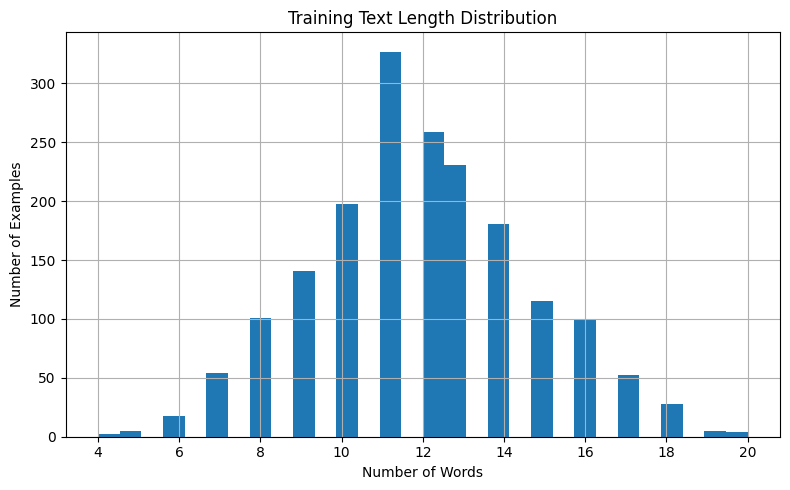


Longest training text:
I do not want danger; I want to stay safe instead of trying to destroy myself or everything around me.
Length: 20

Shortest training text:
I will not overdose.
Length: 4


In [22]:
train_df["text_length"] = train_df["text"].astype(str).str.split().apply(len)

print("Text length summary:")
display(train_df["text_length"].describe())

plt.figure(figsize=(8, 5))
train_df["text_length"].hist(bins=30)
plt.title("Training Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Examples")
plt.tight_layout()
plt.show()

longest_idx = train_df["text_length"].idxmax()
shortest_idx = train_df["text_length"].idxmin()

print("\nLongest training text:")
print(train_df.loc[longest_idx, "text"])
print("Length:", train_df.loc[longest_idx, "text_length"])

print("\nShortest training text:")
print(train_df.loc[shortest_idx, "text"])
print("Length:", train_df.loc[shortest_idx, "text_length"])

## 5. Create Masked / Counterfactual / Replay Data

This section creates the additional training files needed for the mitigation experiments.

Generated files:

```text
data/processed/train_masked.csv
data/processed/train_counterfactual.csv
data/processed/train_full.csv
data/processed/replay_examples.csv

In [23]:
# Create keyword-masked training data.
# Output: data/processed/train_masked.csv

!python -m src.masking

Loading training data...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
Saved masked training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_masked.csv
Total rows: 1820
Masked rows: 883
Mask probability: 0.5

Label distribution:
label
0    906
1    914
Name: count, dtype: int64

Category distribution:
category
ambiguous            367
figurative           363
negation             364
negation_temporal    364
temporal             362
Name: count, dtype: int64


In [24]:
# Create counterfactual training data and full training data.
# Outputs:
# data/processed/train_counterfactual.csv
# data/processed/train_full.csv

!python -m src.augmentation

Loading training data...
Path: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train.csv
Saved counterfactual training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_counterfactual.csv
Original rows: 1820
Counterfactual rows before dedup: 277
Total rows after dedup: 2094

Label distribution:
label
0    1137
1     957
Name: count, dtype: int64

Category distribution:
category
ambiguous            410
figurative           409
negation             445
negation_temporal    426
temporal             404
Name: count, dtype: int64

Source distribution:
source
original          1820
counterfactual     274
Name: count, dtype: int64
Saved full training data to: /home/ubuntu/shortcut-learning-risky-intent/data/processed/train_full.csv
Total rows: 2094
Masked rows: 1013
Mask probability: 0.5

Label distribution:
label
0    1137
1     957
Name: count, dtype: int64

Category distribution:
category
ambiguous            410
figurative           409
negation        

### 5.1 Create Replay Examples

Experience replay uses a small set of hard examples that are repeated during training.

These examples focus on cases that are easy for shortcut-learning models to misunderstand:

- negation
- contraction negation such as `don't`, `won't`, `can't`
- temporal recovery
- negation + temporal recovery
- figurative usage
- direct risky intent

The replay examples are saved as:

```text
data/processed/replay_examples.csv

In [25]:
from pathlib import Path
import pandas as pd

replay_examples = [
    # Negation / contraction non-risky
    {
        "id": "replay_001",
        "text": "I don't want to die.",
        "keyword": "die",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_002",
        "text": "I do not want to hurt myself.",
        "keyword": "hurt",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_003",
        "text": "I won't hurt anyone.",
        "keyword": "hurt",
        "label": 0,
        "category": "negation",
    },
    {
        "id": "replay_004",
        "text": "I can't imagine killing myself.",
        "keyword": "killing",
        "label": 0,
        "category": "negation",
    },

    # Temporal / recovery non-risky
    {
        "id": "replay_005",
        "text": "I used to want to disappear, but I feel safer now.",
        "keyword": "disappear",
        "label": 0,
        "category": "temporal",
    },
    {
        "id": "replay_006",
        "text": "Last year I wanted to hurt myself, but now I am getting help.",
        "keyword": "hurt",
        "label": 0,
        "category": "temporal",
    },

    # Negation + temporal non-risky
    {
        "id": "replay_007",
        "text": "I used to think about killing myself, but I don't feel that way anymore.",
        "keyword": "killing",
        "label": 0,
        "category": "negation_temporal",
    },
    {
        "id": "replay_008",
        "text": "I wanted to jump before, but I won't do that now.",
        "keyword": "jump",
        "label": 0,
        "category": "negation_temporal",
    },

    # Figurative non-risky
    {
        "id": "replay_009",
        "text": "This exam is killing me.",
        "keyword": "killing",
        "label": 0,
        "category": "figurative",
    },
    {
        "id": "replay_010",
        "text": "I am dying of laughter.",
        "keyword": "dying",
        "label": 0,
        "category": "figurative",
    },
    {
        "id": "replay_011",
        "text": "My phone battery died again.",
        "keyword": "died",
        "label": 0,
        "category": "figurative",
    },

    # Risky direct intent
    {
        "id": "replay_012",
        "text": "I want to die tonight.",
        "keyword": "die",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_013",
        "text": "I might hurt myself if I am alone tonight.",
        "keyword": "hurt",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_014",
        "text": "I want to kill myself.",
        "keyword": "kill",
        "label": 1,
        "category": "ambiguous",
    },
    {
        "id": "replay_015",
        "text": "I am thinking about jumping tonight.",
        "keyword": "jumping",
        "label": 1,
        "category": "ambiguous",
    },
]

replay_df = pd.DataFrame(replay_examples)

replay_path = Path("data/processed/replay_examples.csv")
replay_path.parent.mkdir(parents=True, exist_ok=True)
replay_df.to_csv(replay_path, index=False)

print(f"Saved replay examples to: {replay_path}")
print("Replay shape:", replay_df.shape)

print("\nReplay label distribution:")
print(replay_df["label"].value_counts().sort_index())

print("\nReplay category distribution:")
print(replay_df["category"].value_counts().sort_index())

display(replay_df)

Saved replay examples to: data/processed/replay_examples.csv
Replay shape: (15, 5)

Replay label distribution:
label
0    11
1     4
Name: count, dtype: int64

Replay category distribution:
category
ambiguous            4
figurative           3
negation             4
negation_temporal    2
temporal             2
Name: count, dtype: int64


,id,text,keyword,label,category
0,replay_001,I don't want to die.,die,0,negation
1,replay_002,I do not want to hurt myself.,hurt,0,negation
2,replay_003,I won't hurt anyone.,hurt,0,negation
3,replay_004,I can't imagine killing myself.,killing,0,negation
4,replay_005,"I used to want to disappear, but I feel safer ...",disappear,0,temporal
5,replay_006,"Last year I wanted to hurt myself, but now I a...",hurt,0,temporal
6,replay_007,"I used to think about killing myself, but I do...",killing,0,negation_temporal
7,replay_008,"I wanted to jump before, but I won't do that now.",jump,0,negation_temporal
8,replay_009,This exam is killing me.,killing,0,figurative
9,replay_010,I am dying of laughter.,dying,0,figurative


In [26]:
# Quick check that all generated files exist.

generated_files = [
    "data/processed/train.csv",
    "data/processed/train_masked.csv",
    "data/processed/train_counterfactual.csv",
    "data/processed/train_full.csv",
    "data/processed/replay_examples.csv",
    "data/processed/val.csv",
    "data/processed/test.csv",
    "data/processed/ood.csv",
]

for file_path in generated_files:
    path = Path(file_path)
    print(f"{file_path}: {path.exists()}")

data/processed/train.csv: True
data/processed/train_masked.csv: True
data/processed/train_counterfactual.csv: True
data/processed/train_full.csv: True
data/processed/replay_examples.csv: True
data/processed/val.csv: True
data/processed/test.csv: True
data/processed/ood.csv: True


## 6. Run One Experiment + Evaluate + SHAP

For each experiment, this section will:

1. Train the model, except E6 zero-shot.
2. Evaluate on ID test set and OOD test set.
3. Print accuracy, precision, recall, macro-F1, classification report, and confusion matrix.
4. Run SHAP analysis on 3 fixed sentences.

In [27]:
from pathlib import Path
import subprocess
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False


EXPERIMENTS = {
    "E1": {
        "name": "RoBERTa Fine-Tuned Baseline",
        "train": "python -m src.train_roberta --experiment_id E1 --train_file data/processed/train.csv",
        "evaluate": "python -m src.evaluate --experiment_id E1",
        "shap_type": "binary",
    },

    "E2": {
        "name": "RoBERTa + Keyword Masking",
        "train": "python -m src.train_roberta --experiment_id E2 --train_file data/processed/train_masked.csv",
        "evaluate": "python -m src.evaluate --experiment_id E2",
        "shap_type": "binary",
    },

    "E3": {
        "name": "RoBERTa + Counterfactual Augmentation",
        "train": "python -m src.train_roberta --experiment_id E3 --train_file data/processed/train_counterfactual.csv",
        "evaluate": "python -m src.evaluate --experiment_id E3",
        "shap_type": "binary",
    },

    "E4": {
        "name": "RoBERTa + Keyword Masking + Counterfactual Augmentation",
        "train": "python -m src.train_roberta --experiment_id E4 --train_file data/processed/train_full.csv",
        "evaluate": "python -m src.evaluate --experiment_id E4",
        "shap_type": "binary",
    },

    "E5": {
        "name": "RoBERTa + Experience Replay",
        "train": (
            "python -m src.train_roberta "
            "--experiment_id E5 "
            "--train_file data/processed/train.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E5",
        "shap_type": "binary",
    },

    "E6": {
        "name": "NLI Zero-Shot",
        "train": None,
        "evaluate": "python -m src.evaluate_nli_zero_shot --experiment_id E6",
        "shap_type": "nli_zero_shot",
    },

    "E7": {
        "name": "NLI Fine-Tuned",
        "train": "python -m src.train_nli --experiment_id E7 --train_file data/processed/train.csv",
        "evaluate": "python -m src.evaluate --experiment_id E7",
        "shap_type": "binary",
    },

    "E8": {
        "name": "NLI + Keyword Masking + Counterfactual Augmentation",
        "train": "python -m src.train_nli --experiment_id E8 --train_file data/processed/train_full.csv",
        "evaluate": "python -m src.evaluate --experiment_id E8",
        "shap_type": "binary",
    },

    "E9": {
        "name": "NLI + Experience Replay + Counterfactual Augmentation",
        "train": (
            "python -m src.train_transformer "
            "--experiment_id E9 "
            "--model_family nli "
            "--train_file data/processed/train_counterfactual.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E9",
        "shap_type": "binary",
    },

    "E10": {
        "name": "NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation",
        "train": (
            "python -m src.train_transformer "
            "--experiment_id E10 "
            "--model_family nli "
            "--train_file data/processed/train_full.csv "
            "--replay_file data/processed/replay_examples.csv "
            "--replay_repeat 5"
        ),
        "evaluate": "python -m src.evaluate --experiment_id E10",
        "shap_type": "binary",
    },
}

In [28]:
def run_command(command, run=True):
    print("=" * 100)
    print(command)
    print("=" * 100)

    if not run:
        print("Dry run only. Set run=True to execute.")
        return

    result = subprocess.run(
        command,
        shell=True,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(f"Command failed:\n{command}")

In [29]:
def load_metrics(experiment_id):
    metrics_path = Path(f"results/metrics/{experiment_id}.json")

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return None

    with open(metrics_path, "r", encoding="utf-8") as f:
        return json.load(f)


def print_experiment_report(experiment_id, split="id_test", title=None):
    metrics = load_metrics(experiment_id)

    if metrics is None:
        return

    split_metrics = metrics.get(split)

    if split_metrics is None:
        print(f"Split '{split}' not found for {experiment_id}")
        return

    if title is None:
        title = f"{experiment_id} — {split}"

    print("=" * 80)
    print(title)
    print("=" * 80)

    print(f"Accuracy  : {split_metrics.get('accuracy', np.nan):.4f}")
    print(f"Precision : {split_metrics.get('precision', np.nan):.4f}")
    print(f"Recall    : {split_metrics.get('recall', np.nan):.4f}")
    print(f"Macro-F1  : {split_metrics.get('macro_f1', np.nan):.4f}")

    if "average_confidence" in split_metrics:
        print(f"Average confidence    : {split_metrics['average_confidence']:.4f}")

    if "confident_wrong_count" in split_metrics:
        print(f"Confident wrong count : {split_metrics['confident_wrong_count']}")

    print("\nClassification Report:")
    report = split_metrics.get("classification_report")

    if report is not None:
        display(pd.DataFrame(report).T)
    else:
        print("No classification report found.")

    cm = split_metrics.get("confusion_matrix")

    if cm is not None:
        cm = np.array(cm)

        plt.figure(figsize=(5, 4))

        if HAS_SEABORN:
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["non-risky", "risky"],
                yticklabels=["non-risky", "risky"],
            )
        else:
            plt.imshow(cm)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, str(cm[i, j]), ha="center", va="center")
            plt.xticks([0, 1], ["non-risky", "risky"])
            plt.yticks([0, 1], ["non-risky", "risky"])

        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix — {title}")
        plt.tight_layout()
        plt.show()
    else:
        print("No confusion matrix found.")

In [30]:
# If shap is missing, run this once:
# !pip install -q shap

import torch
import shap

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from src import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


SHAP_SENTENCES = [
    "I don't want to die.",
    "I won't cut myself.",
    "I want to die to make everyone happy in this house.",
]

SHAP_EXPECTED = [
    "non-risky",
    "non-risky",
    "risky",
]

SHAP_REASON = [
    "negation with risky keyword",
    "contraction negation with self-harm keyword",
    "direct risky intent with emotional/social context",
]

shap_df = pd.DataFrame(
    {
        "text": SHAP_SENTENCES,
        "expected": SHAP_EXPECTED,
        "reason": SHAP_REASON,
    }
)

display(shap_df)

Using device: cuda


,text,expected,reason
0,I don't want to die.,non-risky,negation with risky keyword
1,I won't cut myself.,non-risky,contraction negation with self-harm keyword
2,I want to die to make everyone happy in this h...,risky,direct risky intent with emotional/social context


In [31]:
def load_binary_model_for_shap(experiment_id):
    model_path = Path("saved_models") / experiment_id

    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    model.to(device)
    model.eval()

    return tokenizer, model


def make_binary_predict_proba(tokenizer, model):
    def predict_proba(texts):
        if isinstance(texts, str):
            texts = [texts]

        texts = [str(text) for text in texts]
        all_probs = []

        for text in texts:
            encoding = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=config.MAX_LEN,
                return_tensors="pt",
            )

            encoding = {key: value.to(device) for key, value in encoding.items()}

            with torch.no_grad():
                outputs = model(**encoding)
                probs = torch.softmax(outputs.logits, dim=1)

            all_probs.append(probs.cpu().numpy()[0])

        return np.array(all_probs)

    return predict_proba

In [32]:
RISKY_HYPOTHESIS = "This text expresses risky intent."
NON_RISKY_HYPOTHESIS = "This text does not express risky intent."


def find_entailment_index(model):
    id2label = model.config.id2label

    for idx, label in id2label.items():
        if "entail" in str(label).lower():
            return int(idx)

    if model.config.num_labels == 3:
        return 2

    raise ValueError(f"Could not find entailment label from id2label: {id2label}")


def load_nli_zero_shot_for_shap():
    model_name = getattr(config, "NLI_MODEL_NAME", "cross-encoder/nli-roberta-base")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    model.to(device)
    model.eval()

    entailment_index = find_entailment_index(model)

    return tokenizer, model, entailment_index


def make_nli_zero_shot_predict_proba(tokenizer, model, entailment_index):
    def get_entailment_score(text, hypothesis):
        encoding = tokenizer(
            text,
            hypothesis,
            truncation=True,
            padding="max_length",
            max_length=config.MAX_LEN,
            return_tensors="pt",
        )

        encoding = {key: value.to(device) for key, value in encoding.items()}

        with torch.no_grad():
            outputs = model(**encoding)
            probs = torch.softmax(outputs.logits, dim=1)

        return probs[0][entailment_index].item()

    def predict_proba(texts):
        if isinstance(texts, str):
            texts = [texts]

        texts = [str(text) for text in texts]
        all_probs = []

        for text in texts:
            risky_score = get_entailment_score(text, RISKY_HYPOTHESIS)
            non_risky_score = get_entailment_score(text, NON_RISKY_HYPOTHESIS)

            scores = np.array([non_risky_score, risky_score], dtype=float)

            if scores.sum() == 0:
                probs = np.array([0.5, 0.5])
            else:
                probs = scores / scores.sum()

            all_probs.append(probs)

        return np.array(all_probs)

    return predict_proba

In [33]:
def run_shap_for_experiment(experiment_id, max_display=12):
    print("\n" + "=" * 100)
    print(f"SHAP ANALYSIS — {experiment_id}: {EXPERIMENTS[experiment_id]['name']}")
    print("=" * 100)

    shap_type = EXPERIMENTS[experiment_id]["shap_type"]

    if shap_type == "nli_zero_shot":
        tokenizer, model, entailment_index = load_nli_zero_shot_for_shap()
        predict_proba = make_nli_zero_shot_predict_proba(
            tokenizer=tokenizer,
            model=model,
            entailment_index=entailment_index,
        )
    else:
        tokenizer, model = load_binary_model_for_shap(experiment_id)
        predict_proba = make_binary_predict_proba(tokenizer, model)

    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_proba, masker)

    texts = shap_df["text"].tolist()

    # Lower max_evals makes SHAP faster.
    shap_values = explainer(texts, max_evals=100)

    for i, row in shap_df.iterrows():
        sentence_number = i + 1
        text = row["text"]

        probs = predict_proba([text])[0]
        pred_id = int(np.argmax(probs))
        pred_label = "risky" if pred_id == 1 else "non-risky"

        print("\n" + "=" * 100)
        print(f"Sentence {sentence_number}: {text}")
        print("=" * 100)
        print(f"Expected: {row['expected']}")
        print(f"Reason  : {row['reason']}")
        print(f"Prediction: {pred_label}")
        print(f"Non-risky probability: {probs[0]:.4f}")
        print(f"Risky probability    : {probs[1]:.4f}")

        print("\nSHAP waterfall explanation for risky class:")
        shap.plots.waterfall(shap_values[i, :, 1], max_display=max_display)

In [34]:
def run_one_experiment(
    experiment_id,
    run_training=True,
    run_evaluation=True,
    run_shap=True,
):
    experiment = EXPERIMENTS[experiment_id]

    print("\n" + "#" * 100)
    print(f"{experiment_id}: {experiment['name']}")
    print("#" * 100)

    # 1. Train
    if experiment["train"] is None:
        print(f"{experiment_id} is zero-shot. Skipping training.")
    else:
        if run_training:
            print("\nTRAINING")
            run_command(experiment["train"], run=True)
        else:
            print("\nSkipping training.")
            print("Training command:")
            print(experiment["train"])

    # 2. Evaluate
    if run_evaluation:
        print("\nEVALUATION")
        run_command(experiment["evaluate"], run=True)

        print_experiment_report(
            experiment_id=experiment_id,
            split="id_test",
            title=f"{experiment_id} — {experiment['name']} — ID Test",
        )

        print_experiment_report(
            experiment_id=experiment_id,
            split="ood",
            title=f"{experiment_id} — {experiment['name']} — OOD Test",
        )
    else:
        print("\nSkipping evaluation.")
        print("Evaluation command:")
        print(experiment["evaluate"])

    # 3. SHAP
    if run_shap:
        print("\nSHAP")
        run_shap_for_experiment(experiment_id)
    else:
        print("\nSkipping SHAP.")

In [35]:
from pathlib import Path
import os

print("Current directory:")
print(Path.cwd())

print("\nFiles here:")
print([p.name for p in Path.cwd().iterdir()][:30])

Current directory:
/home/ubuntu/shortcut-learning-risky-intent

Files here:
['notebooks', 'src', 'requirements.txt', '.git', '.ipynb_checkpoints', 'results', 'data', 'saved_models', 'README.md', '.gitignore']


In [36]:
from pathlib import Path

print(Path.cwd())
print("src exists:", Path("src").exists())
print("data exists:", Path("data").exists())

/home/ubuntu/shortcut-learning-risky-intent
src exists: True
data exists: True


In [37]:
!df -h
!du -sh saved_models results data 2>/dev/null

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   31G   18G  64% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme
4.0K	saved_models
4.0K	results
1.4M	data


In [38]:
%cd /home/ubuntu/shortcut-learning-risky-intent

!rm -rf saved_models/E1
!rm -rf saved_models/E2
!rm -rf saved_models/E3
!rm -rf saved_models/E4
!rm -rf saved_models/E5
!rm -rf saved_models/E7
!rm -rf saved_models/E8
!rm -rf saved_models/E9
!rm -rf saved_models/E10

!find saved_models -type d -name "checkpoint-*" -exec rm -rf {} +

!rm -rf results/predictions/*.csv
!rm -rf results/metrics/*.json
!rm -rf results/plots/*.png

!df -h

/home/ubuntu/shortcut-learning-risky-intent
Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   31G   18G  64% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme


In [39]:
!df -h
!du -sh /home/ubuntu/* 2>/dev/null | sort -h
!du -sh /home/ubuntu/shortcut-learning-risky-intent/* 2>/dev/null | sort -h
!du -sh /home/ubuntu/.cache/* 2>/dev/null | sort -h

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   31G   18G  64% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme
4.0K	/home/ubuntu/THIRD_PARTY_SOURCE_CODE_URLS
4.0K	/home/ubuntu/setup-jupyter.sh
20K	/home/ubuntu/OSSNvidiaDriver_v580.126.16_license.txt
44K	/home/ubuntu/BUILD_FROM_SOURCE_PACKAGES_LICENCES
116K	/home/ubuntu/LINUX_PACKAGES_LIST
360K	/home/ubuntu/2505_robertaNLI_ju.ipynb
2.1M	/home/ubuntu/PYTHON_PACKAGES_LICENSES
9.1M	/home/ubuntu/LINUX_PACKAGES_LICENSES
9.9M	/home/ubuntu/shortcut-learning-risky-intent
4.0K	/home/u

In [40]:
!rm -rf /home/ubuntu/.cache/pip
!rm -rf /home/ubuntu/.cache/huggingface
!df -h

Filesystem                      Size  Used Avail Use% Mounted on
/dev/root                        48G   28G   21G  58% /
tmpfs                           7.6G     0  7.6G   0% /dev/shm
tmpfs                           3.1G  1.2M  3.0G   1% /run
tmpfs                           5.0M     0  5.0M   0% /run/lock
efivarfs                        128K  3.8K  120K   4% /sys/firmware/efi/efivars
/dev/nvme0n1p16                 881M  180M  640M  22% /boot
/dev/nvme0n1p15                 105M  6.2M   99M   6% /boot/efi
/dev/mapper/vg.01-lv_ephemeral  229G   28K  217G   1% /opt/dlami/nvme


In [41]:
import os

os.environ["HF_HOME"] = "/opt/dlami/nvme/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/opt/dlami/nvme/hf_cache"
os.environ["HF_DATASETS_CACHE"] = "/opt/dlami/nvme/hf_cache/datasets"
os.environ["TMPDIR"] = "/opt/dlami/nvme/tmp"

print("HF_HOME:", os.environ["HF_HOME"])

HF_HOME: /opt/dlami/nvme/hf_cache



####################################################################################################
E1: RoBERTa Fine-Tuned Baseline
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E1 --train_file data/processed/train.csv



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E1
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 27.37 GB
Free : 20.00 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 27.37 GB
Free : 20.00 GB
Loading dataset from: data/processed/train.csv
Loaded 1820 rows.
Label distribution:
label
0    906
1    914
Name: count, dtype: int64
Loading dataset from: /home/ubun

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4661.68it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E1

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E1_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 27.84 GB
Free : 19.53 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 27.84 GB
Free : 19.53 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E1
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E1


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4641.50it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E1_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E1_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E1.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.5600
OOD macro F1: 0.5503
OOD confident wrong count: 63
E1 — RoBERTa Fine-Tuned Baseline — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9999
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


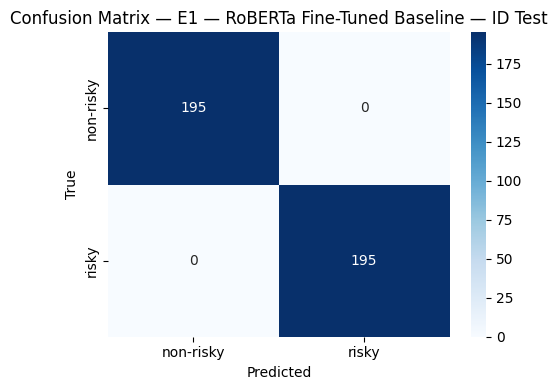

E1 — RoBERTa Fine-Tuned Baseline — OOD Test
Accuracy  : 0.5600
Precision : 0.5553
Recall    : 0.5527
Macro-F1  : 0.5503
Average confidence    : 0.9858
Confident wrong count : 63

Classification Report:


,precision,recall,f1-score,support
non-risky,0.576087,0.662500,0.616279,80.00
risky,0.534483,0.442857,0.484375,70.00
accuracy,0.560000,0.560000,0.560000,0.56
macro avg,0.555285,0.552679,0.550327,150.00
weighted avg,0.556672,0.560000,0.554724,150.00


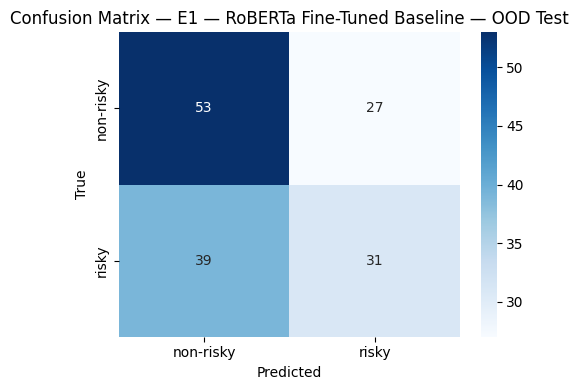


SHAP

SHAP ANALYSIS — E1: RoBERTa Fine-Tuned Baseline


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


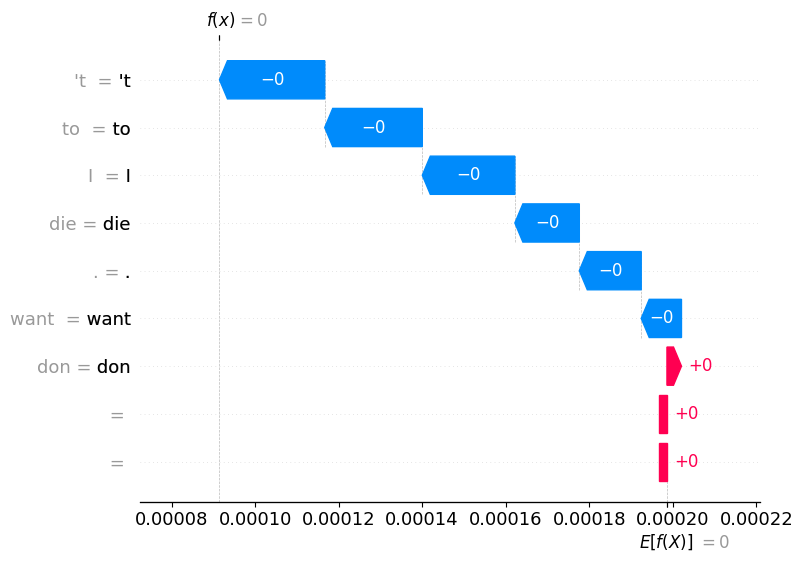


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


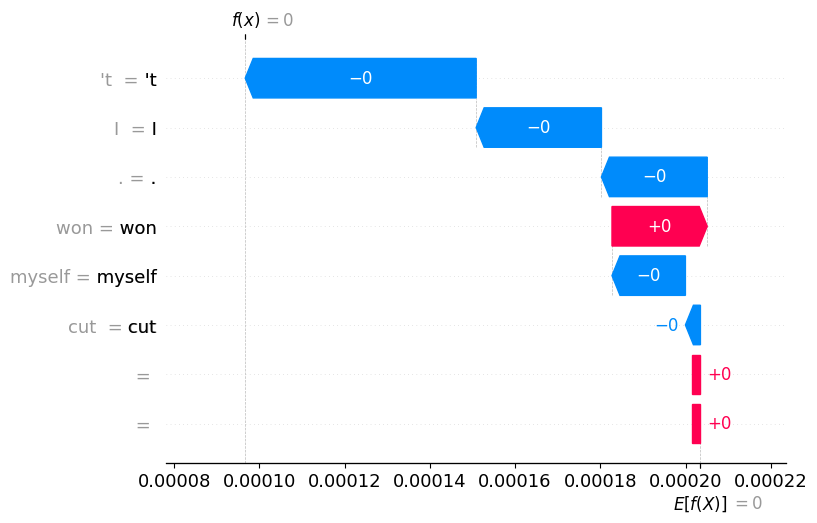


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9884
Risky probability    : 0.0116

SHAP waterfall explanation for risky class:


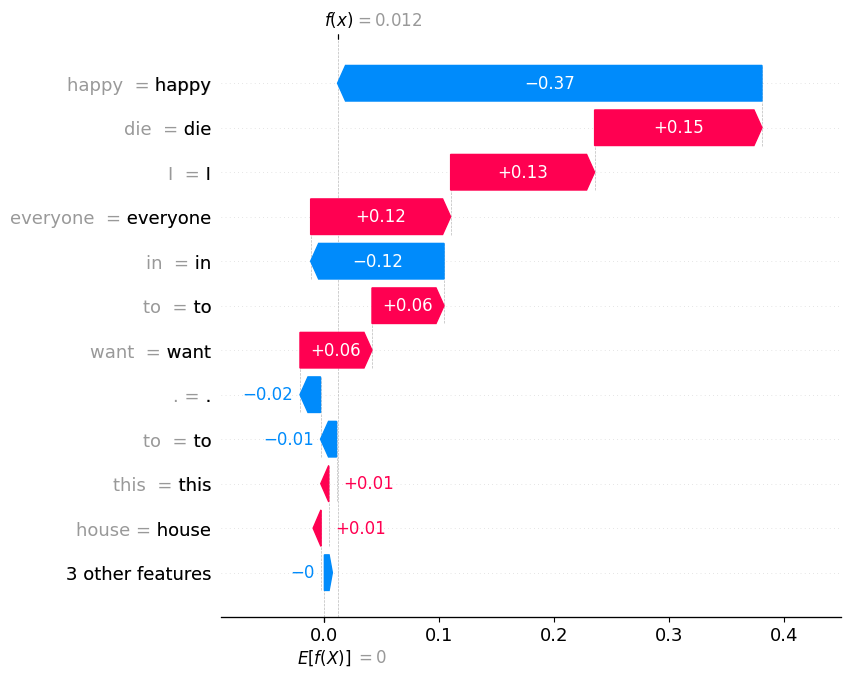

In [42]:
run_one_experiment(
    experiment_id="E1",
    run_training=True,
    run_evaluation=True,
    run_shap=True,
)


####################################################################################################
E2: RoBERTa + Keyword Masking
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E2 --train_file data/processed/train_masked.csv



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E2
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB
Loading dataset from: data/processed/train_masked.csv
Loaded 1820 rows.
Label distribution:
label
0    906
1    914
Name: count, dtype: int64
Loading dataset from: /ho

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4717.54it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E2

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E2_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E2
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E2


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4770.57it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E2_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E2_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E2.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6200
OOD macro F1: 0.5981
OOD confident wrong count: 55
E2 — RoBERTa + Keyword Masking — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9999
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


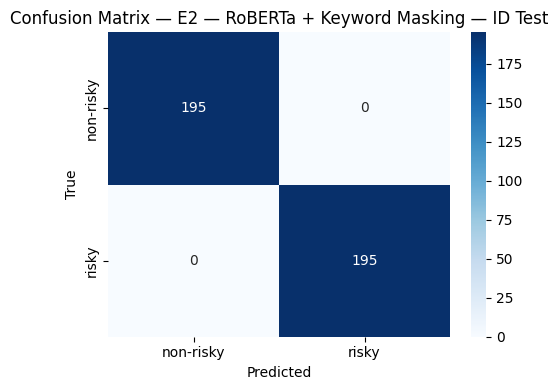

E2 — RoBERTa + Keyword Masking — OOD Test
Accuracy  : 0.6200
Precision : 0.6270
Recall    : 0.6071
Macro-F1  : 0.5981
Average confidence    : 0.9843
Confident wrong count : 55

Classification Report:


,precision,recall,f1-score,support
non-risky,0.609524,0.800000,0.691892,80.00
risky,0.644444,0.414286,0.504348,70.00
accuracy,0.620000,0.620000,0.620000,0.62
macro avg,0.626984,0.607143,0.598120,150.00
weighted avg,0.625820,0.620000,0.604371,150.00


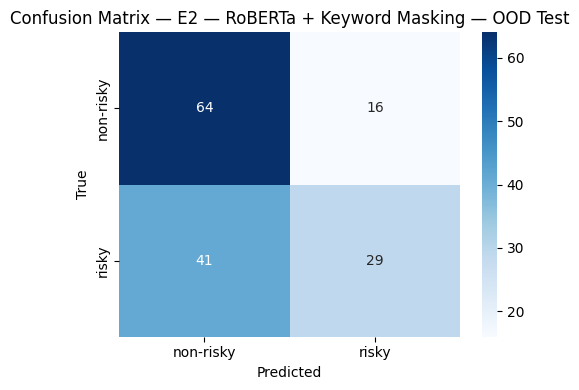


SHAP

SHAP ANALYSIS — E2: RoBERTa + Keyword Masking


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


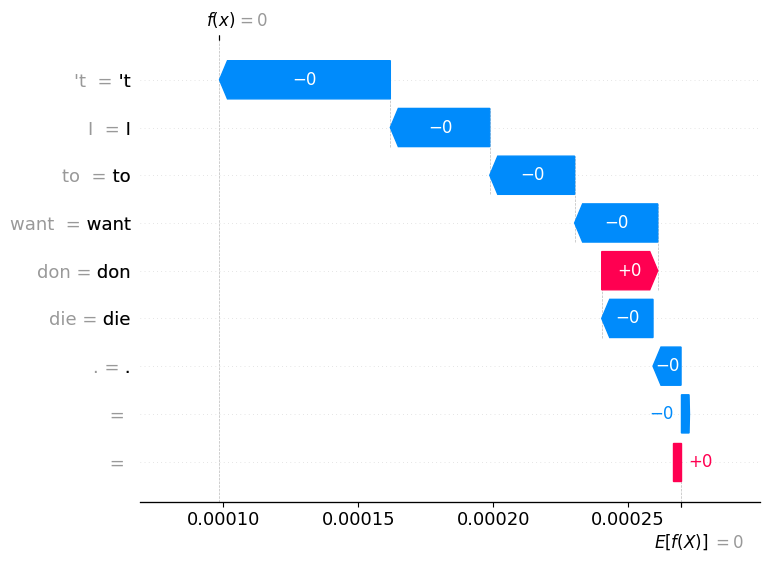


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


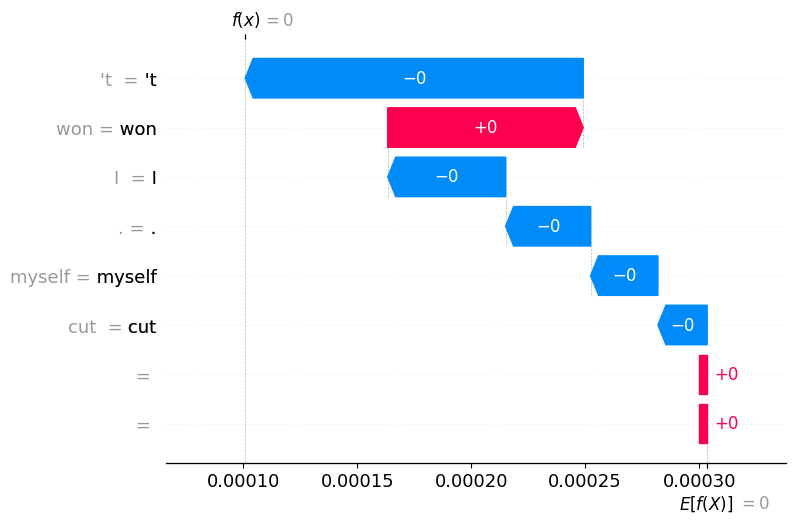


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9988
Risky probability    : 0.0012

SHAP waterfall explanation for risky class:


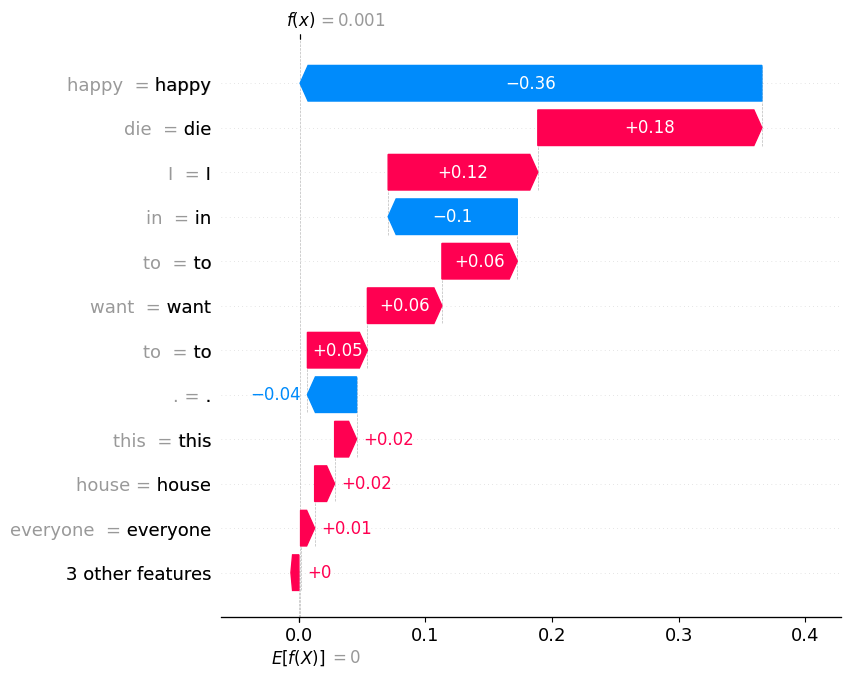

In [44]:
run_one_experiment(
    "E2", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E3: RoBERTa + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E3 --train_file data/processed/train_counterfactual.csv



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E3
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 28.31 GB
Free : 19.07 GB
Loading dataset from: data/processed/train_counterfactual.csv
Loaded 2094 rows.
Label distribution:
label
0    1137
1     957
Name: count, dtype: int64
Loading dataset

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4635.37it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E3

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E3_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 28.78 GB
Free : 18.60 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 28.78 GB
Free : 18.60 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E3
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E3


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4615.91it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E3_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E3_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E3.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6600
OOD macro F1: 0.6296
OOD confident wrong count: 51
E3 — RoBERTa + Counterfactual Augmentation — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9999
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


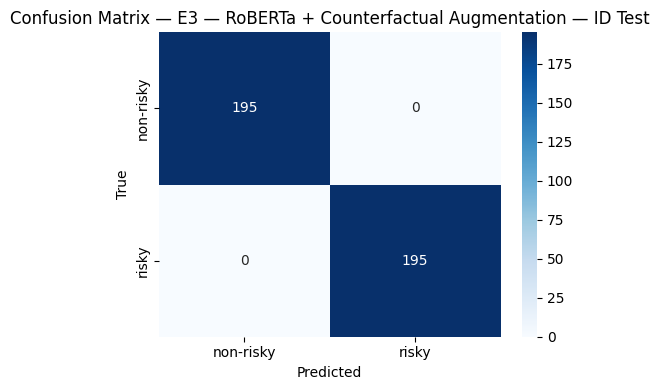

E3 — RoBERTa + Counterfactual Augmentation — OOD Test
Accuracy  : 0.6600
Precision : 0.6925
Recall    : 0.6438
Macro-F1  : 0.6296
Average confidence    : 0.9944
Confident wrong count : 51

Classification Report:


,precision,recall,f1-score,support
non-risky,0.628319,0.88750,0.735751,80.00
risky,0.756757,0.40000,0.523364,70.00
accuracy,0.660000,0.66000,0.660000,0.66
macro avg,0.692538,0.64375,0.629558,150.00
weighted avg,0.688256,0.66000,0.636637,150.00


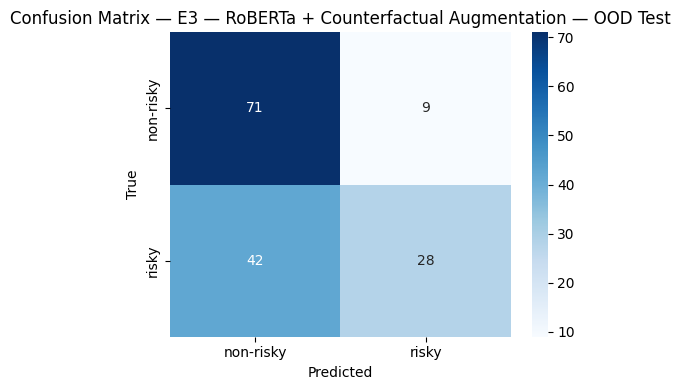


SHAP

SHAP ANALYSIS — E3: RoBERTa + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


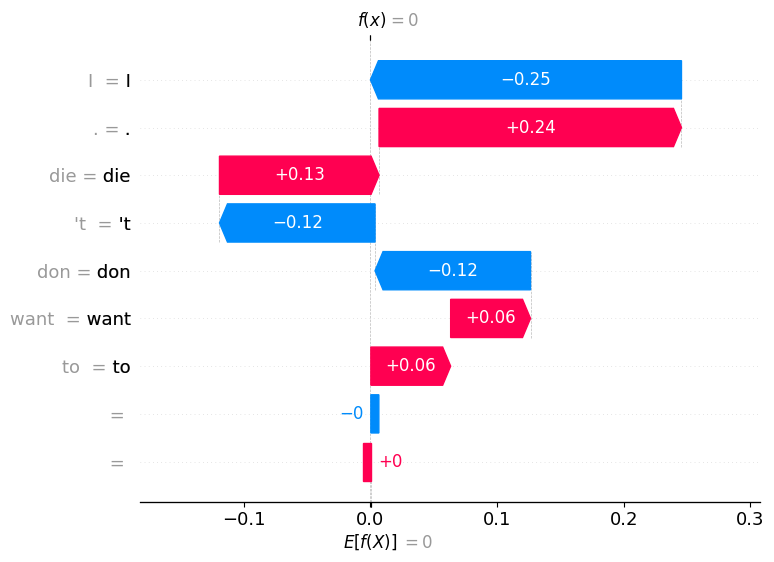


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


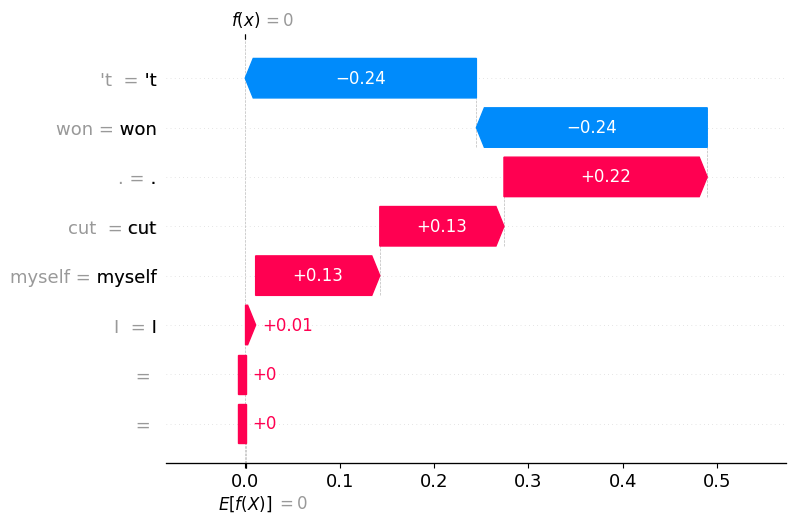


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: risky
Non-risky probability: 0.0740
Risky probability    : 0.9260

SHAP waterfall explanation for risky class:


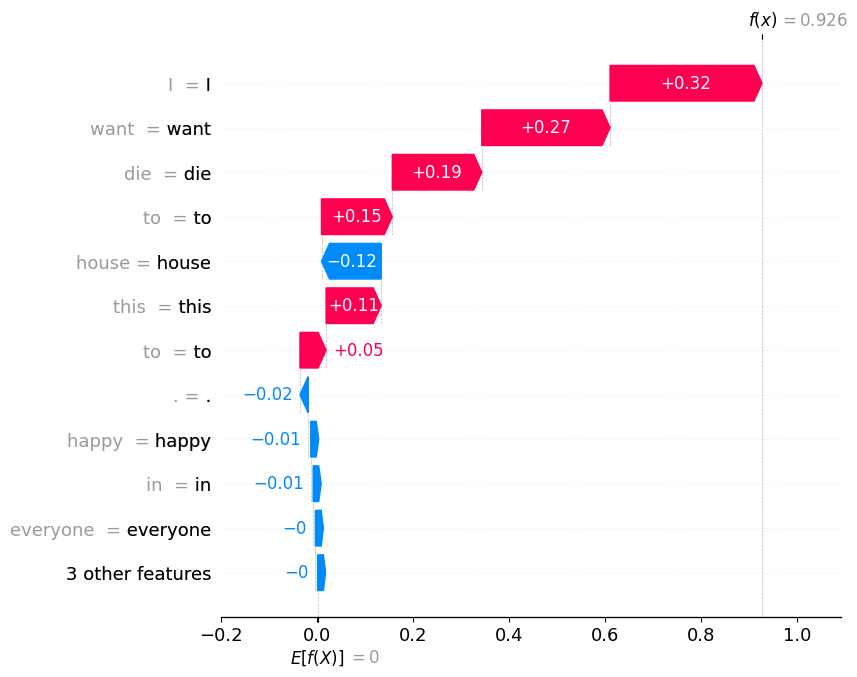

In [45]:
run_one_experiment(
    "E3", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E4: RoBERTa + Keyword Masking + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E4 --train_file data/processed/train_full.csv

TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E4
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-inten

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4771.35it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


 12%|█▏        | 3/25 [00:00<00:00, 29.69it/s]

{'loss': '0.6881', 'grad_norm': '4.654', 'learning_rate': '1.903e-05', 'epoch': '0.1527'}
{'loss': '0.4246', 'grad_norm': '12.47', 'learning_rate': '1.802e-05', 'epoch': '0.3053'}
{'loss': '0.09254', 'grad_norm': '41.64', 'learning_rate': '1.7e-05', 'epoch': '0.458'}
{'loss': '0.05355', 'grad_norm': '0.8146', 'learning_rate': '1.598e-05', 'epoch': '0.6107'}
{'loss': '0.009402', 'grad_norm': '0.01826', 'learning_rate': '1.496e-05', 'epoch': '0.7634'}
{'loss': '0.001476', 'grad_norm': '0.01465', 'learning_rate': '1.394e-05', 'epoch': '0.916'}


...

Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.50s/it]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E4

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E4_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E4
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E4


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4872.33it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E4_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E4_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E4.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6800
OOD macro F1: 0.6555
OOD confident wrong count: 45
E4 — RoBERTa + Keyword Masking + Counterfactual Augmentation — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9992
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


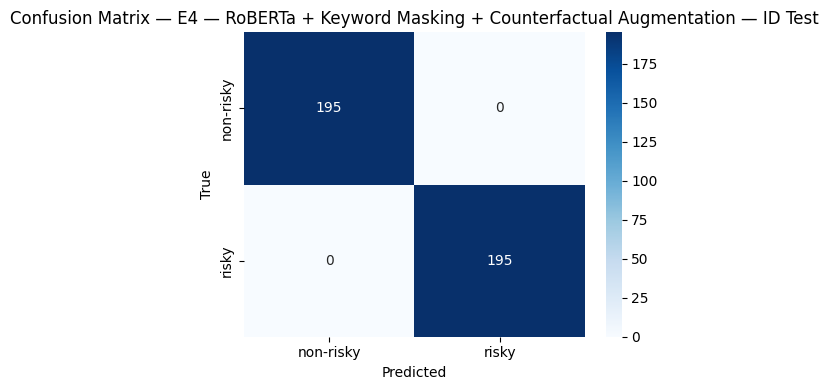

E4 — RoBERTa + Keyword Masking + Counterfactual Augmentation — OOD Test
Accuracy  : 0.6800
Precision : 0.7102
Recall    : 0.6652
Macro-F1  : 0.6555
Average confidence    : 0.9834
Confident wrong count : 45

Classification Report:


,precision,recall,f1-score,support
non-risky,0.645455,0.887500,0.747368,80.00
risky,0.775000,0.442857,0.563636,70.00
accuracy,0.680000,0.680000,0.680000,0.68
macro avg,0.710227,0.665179,0.655502,150.00
weighted avg,0.705909,0.680000,0.661627,150.00


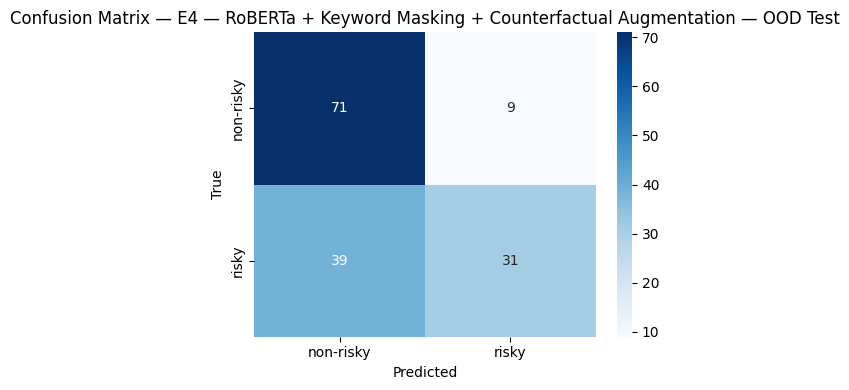


SHAP

SHAP ANALYSIS — E4: RoBERTa + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


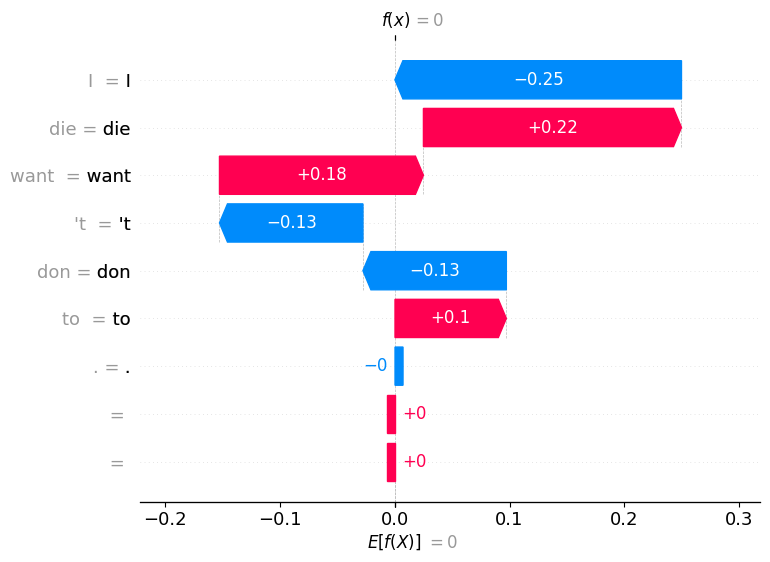


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


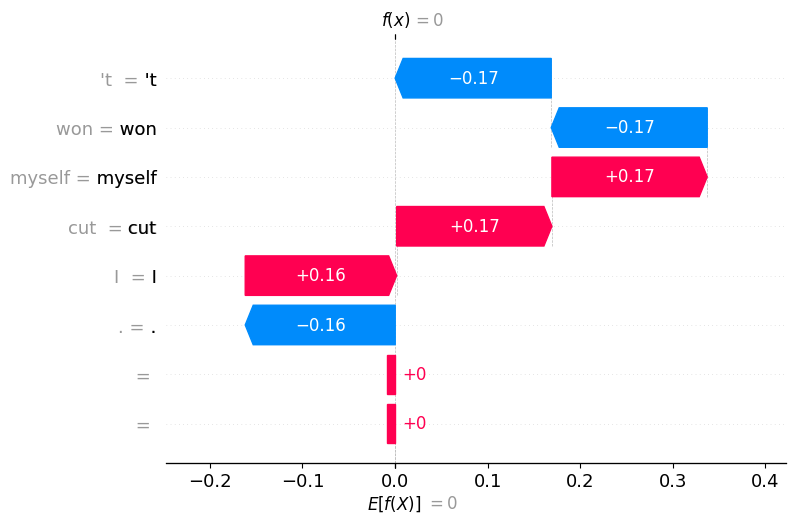


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: risky
Non-risky probability: 0.0008
Risky probability    : 0.9992

SHAP waterfall explanation for risky class:


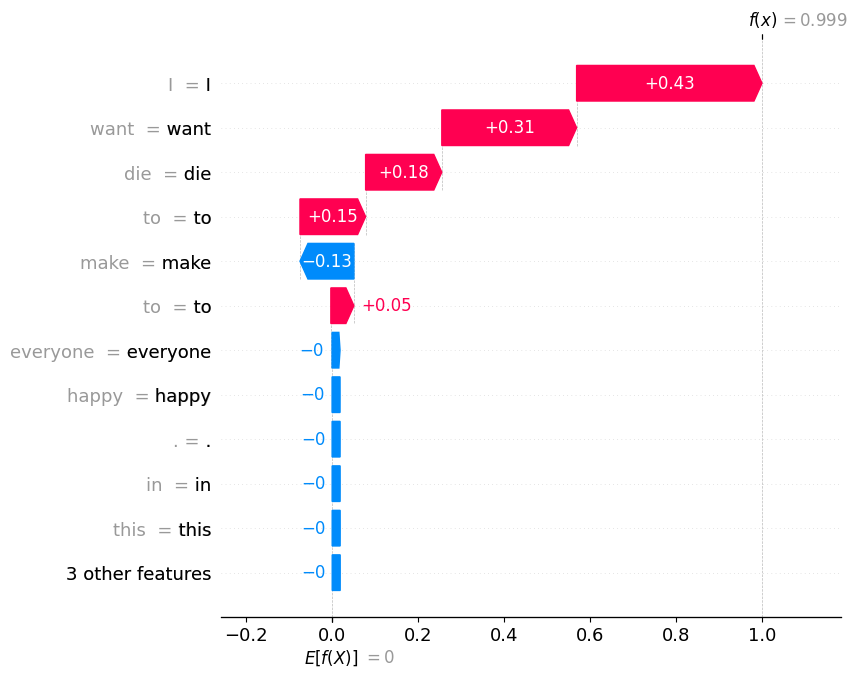

In [50]:
run_one_experiment(
    "E4", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E5: RoBERTa + Experience Replay
####################################################################################################

TRAINING
python -m src.train_roberta --experiment_id E5 --train_file data/processed/train.csv --replay_file data/processed/replay_examples.csv --replay_repeat 5

TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E5
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ub

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4952.75it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


 33%|███▎      | 118/357 [00:18<00:37,  6.36it/s]

{'loss': '0.654', 'grad_norm': '3.789', 'learning_rate': '1.894e-05', 'epoch': '0.1681'}
{'loss': '0.3245', 'grad_norm': '2.281', 'learning_rate': '1.782e-05', 'epoch': '0.3361'}
{'loss': '0.1189', 'grad_norm': '1.48', 'learning_rate': '1.669e-05', 'epoch': '0.5042'}
{'loss': '0.007039', 'grad_norm': '0.05658', 'learning_rate': '1.557e-05', 'epoch': '0.6723'}
{'loss': '0.001423', 'grad_norm': '0.05257', 'learning_rate': '1.445e-05', 'epoch': '0.8403'}


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E5

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E5_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E5
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E5


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4748.46it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E5_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E5_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E5.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6667
OOD macro F1: 0.6546
OOD confident wrong count: 49
E5 — RoBERTa + Experience Replay — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9999
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


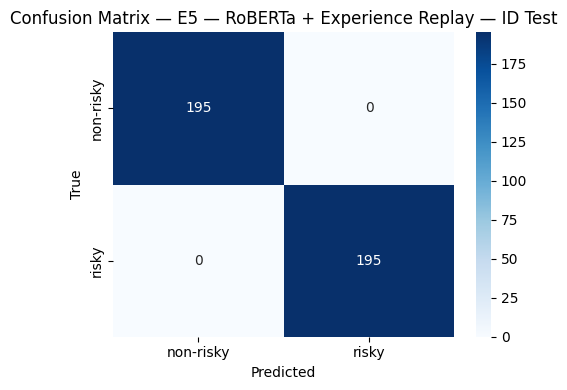

E5 — RoBERTa + Experience Replay — OOD Test
Accuracy  : 0.6667
Precision : 0.6727
Recall    : 0.6571
Macro-F1  : 0.6546
Average confidence    : 0.9893
Confident wrong count : 49

Classification Report:


,precision,recall,f1-score,support
non-risky,0.653061,0.800000,0.719101,80.000000
risky,0.692308,0.514286,0.590164,70.000000
accuracy,0.666667,0.666667,0.666667,0.666667
macro avg,0.672684,0.657143,0.654633,150.000000
weighted avg,0.671376,0.666667,0.658930,150.000000


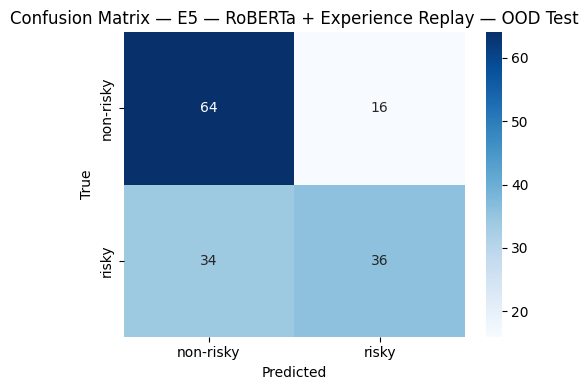


SHAP

SHAP ANALYSIS — E5: RoBERTa + Experience Replay


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


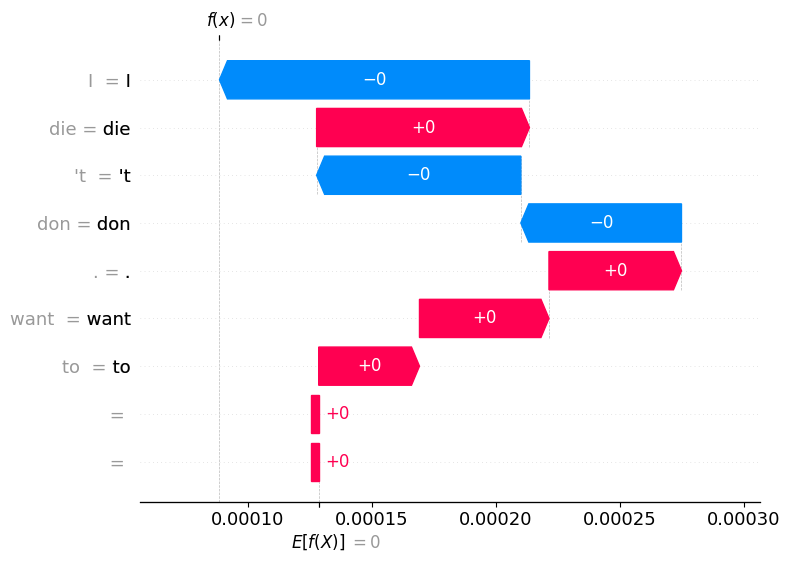


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9999
Risky probability    : 0.0001

SHAP waterfall explanation for risky class:


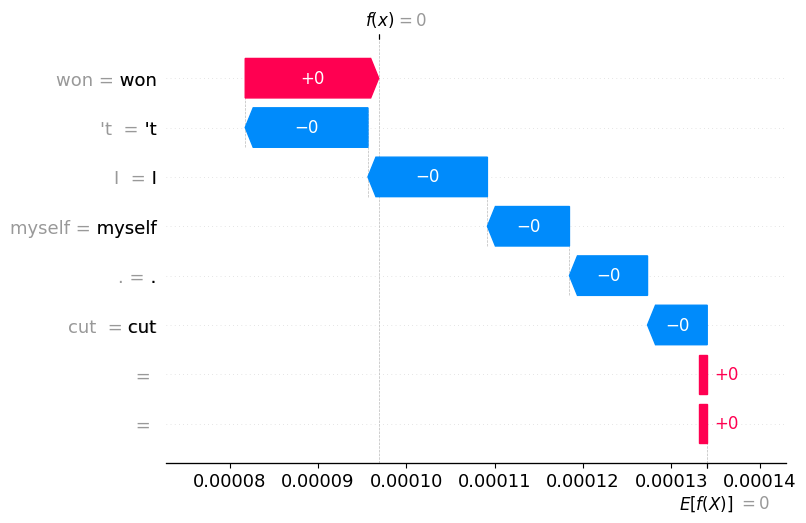


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: risky
Non-risky probability: 0.0450
Risky probability    : 0.9550

SHAP waterfall explanation for risky class:


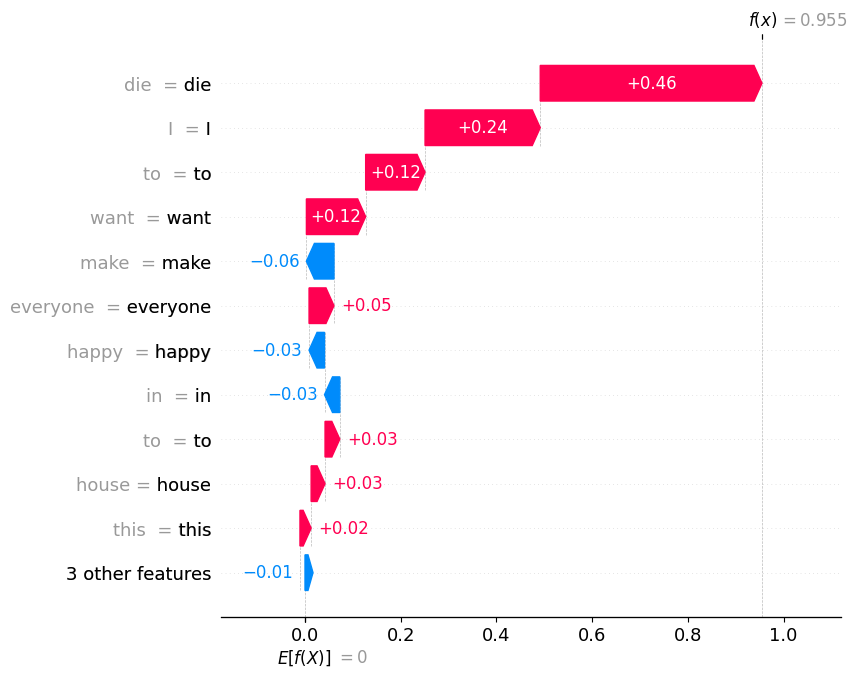

In [48]:
run_one_experiment(
    "E5", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True)

In [49]:
run_one_experiment(
    "E6", 
    run_training=False, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E6: NLI Zero-Shot
####################################################################################################
E6 is zero-shot. Skipping training.

EVALUATION
python -m src.evaluate_nli_zero_shot --experiment_id E6


/opt/jupyter/venv/bin/python: No module named src.evaluate_nli_zero_shot


RuntimeError: Command failed:
python -m src.evaluate_nli_zero_shot --experiment_id E6


####################################################################################################
E7: NLI Fine-Tuned
####################################################################################################

TRAINING
python -m src.train_nli --experiment_id E7 --train_file data/processed/train.csv


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E7
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 29.71 GB
Free : 17.66 GB
Loading dataset from: data/processed/train.csv
Loaded 1820 rows.
Label distribution:
label
0    906
1    914
Name: count, dtype: int64
Loading dataset from: /home/ubun

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4600.15it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E7

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E7_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 30.18 GB
Free : 17.20 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 30.18 GB
Free : 17.20 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E7
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E7


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4834.20it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E7_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E7_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E7.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.5800
OOD macro F1: 0.5343
OOD confident wrong count: 61
E7 — NLI Fine-Tuned — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9998
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


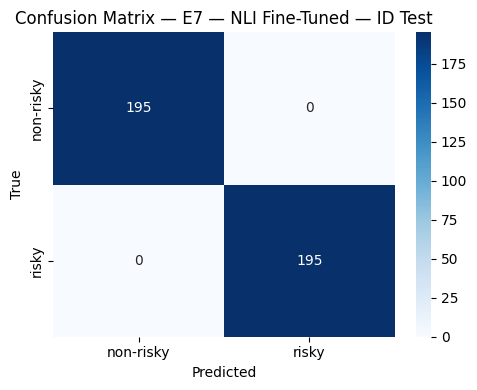

E7 — NLI Fine-Tuned — OOD Test
Accuracy  : 0.5800
Precision : 0.5894
Recall    : 0.5616
Macro-F1  : 0.5343
Average confidence    : 0.9922
Confident wrong count : 61

Classification Report:


,precision,recall,f1-score,support
non-risky,0.572650,0.837500,0.680203,80.00
risky,0.606061,0.285714,0.388350,70.00
accuracy,0.580000,0.580000,0.580000,0.58
macro avg,0.589355,0.561607,0.534276,150.00
weighted avg,0.588241,0.580000,0.544005,150.00


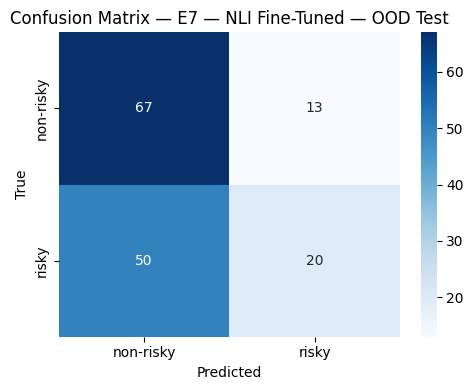


SHAP

SHAP ANALYSIS — E7: NLI Fine-Tuned


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9997
Risky probability    : 0.0003

SHAP waterfall explanation for risky class:


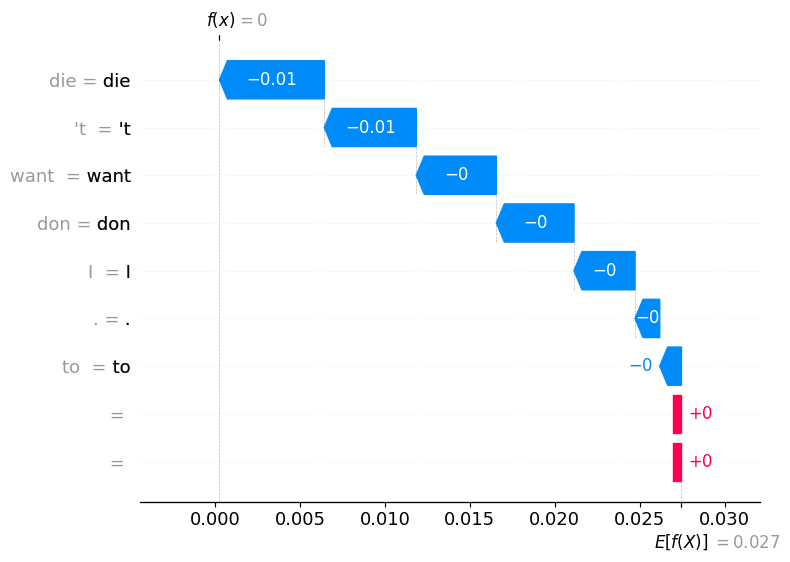


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


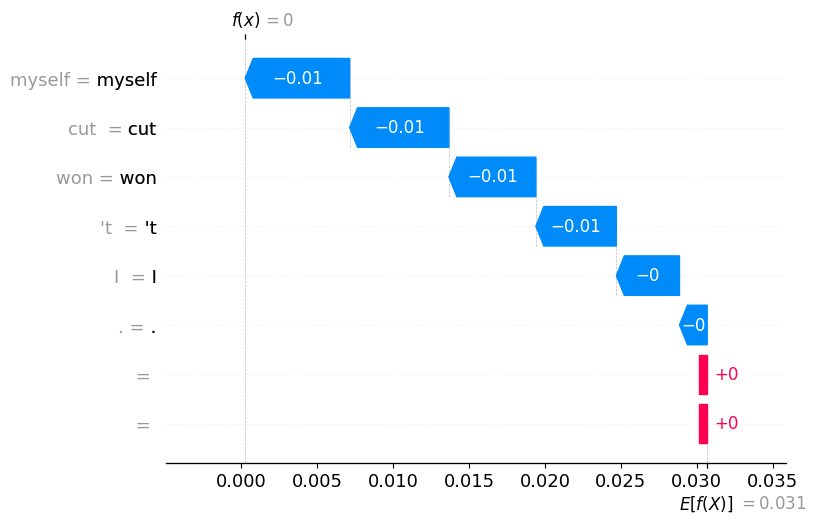


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9995
Risky probability    : 0.0005

SHAP waterfall explanation for risky class:


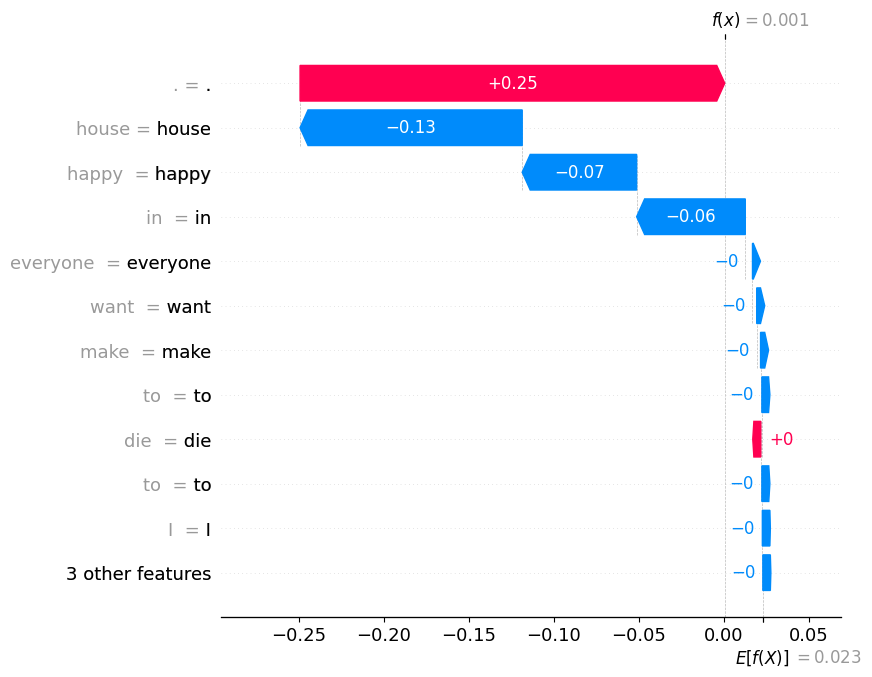

In [51]:
run_one_experiment(
    "E7", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E8: NLI + Keyword Masking + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_nli --experiment_id E8 --train_file data/processed/train_full.csv


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E8
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 30.18 GB
Free : 17.20 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 30.18 GB
Free : 17.20 GB
Loading dataset from: data/processed/train_full.csv
Loaded 2094 rows.
Label distribution:
label
0    1137
1     957
Name: count, dtype: int64
Loading dataset from: /ho

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4537.04it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E8

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E8_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 30.65 GB
Free : 16.73 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 30.65 GB
Free : 16.73 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E8
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E8


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4637.85it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E8_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E8_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E8.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6600
OOD macro F1: 0.6468
OOD confident wrong count: 50
E8 — NLI + Keyword Masking + Counterfactual Augmentation — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9998
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


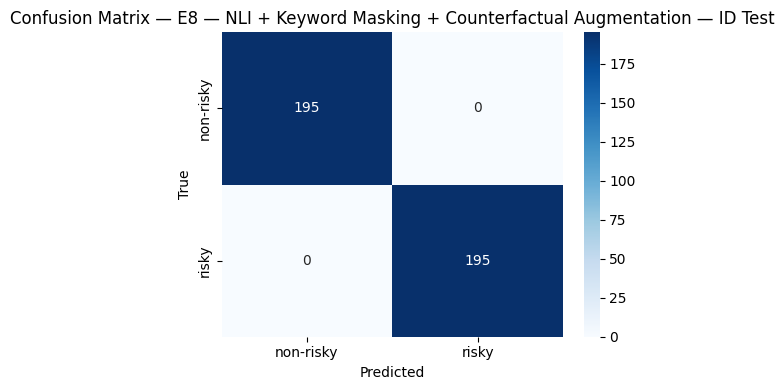

E8 — NLI + Keyword Masking + Counterfactual Augmentation — OOD Test
Accuracy  : 0.6600
Precision : 0.6664
Recall    : 0.6500
Macro-F1  : 0.6468
Average confidence    : 0.9910
Confident wrong count : 50

Classification Report:


,precision,recall,f1-score,support
non-risky,0.646465,0.80,0.715084,80.00
risky,0.686275,0.50,0.578512,70.00
accuracy,0.660000,0.66,0.660000,0.66
macro avg,0.666370,0.65,0.646798,150.00
weighted avg,0.665043,0.66,0.651350,150.00


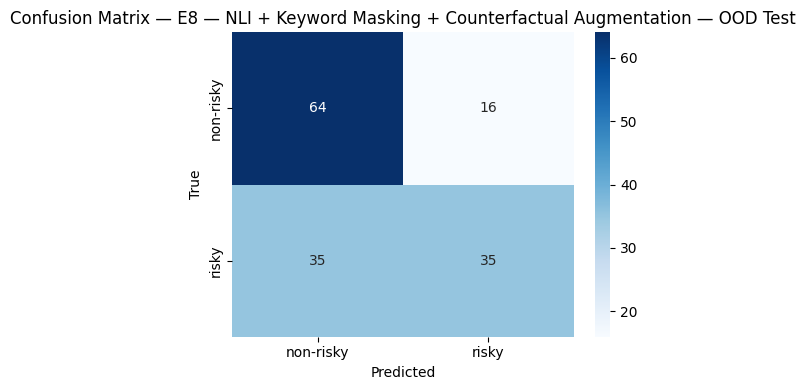


SHAP

SHAP ANALYSIS — E8: NLI + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


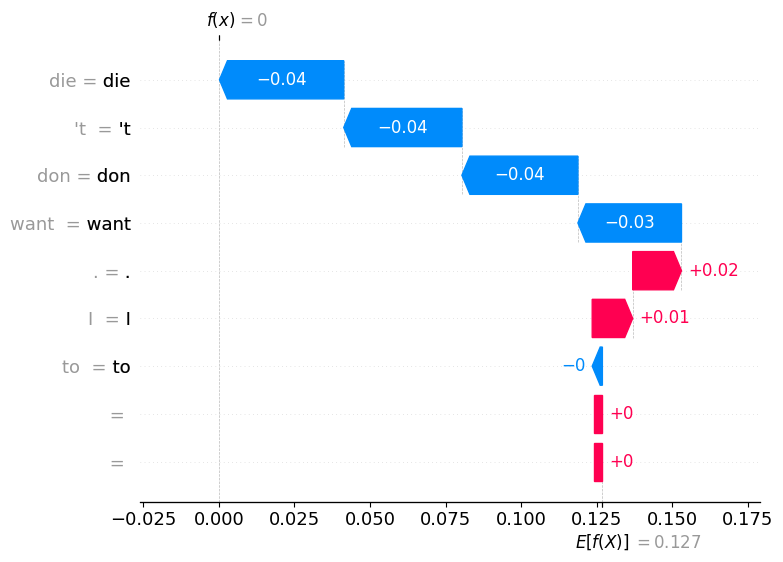


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


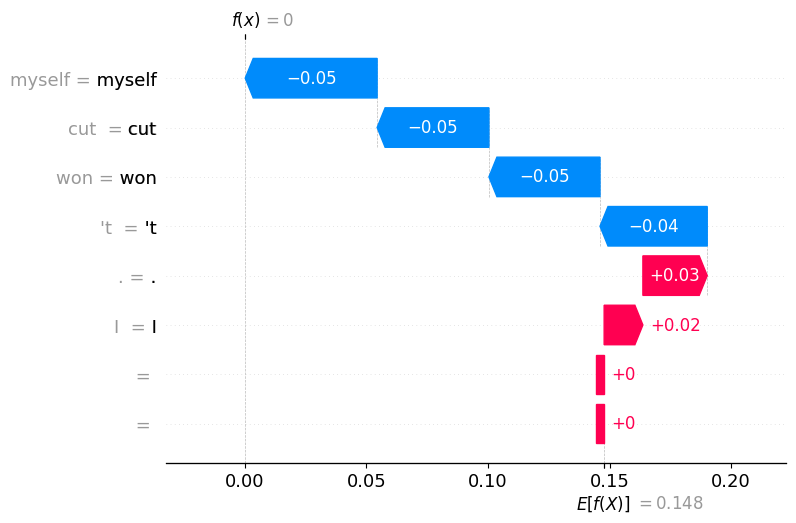


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9929
Risky probability    : 0.0071

SHAP waterfall explanation for risky class:


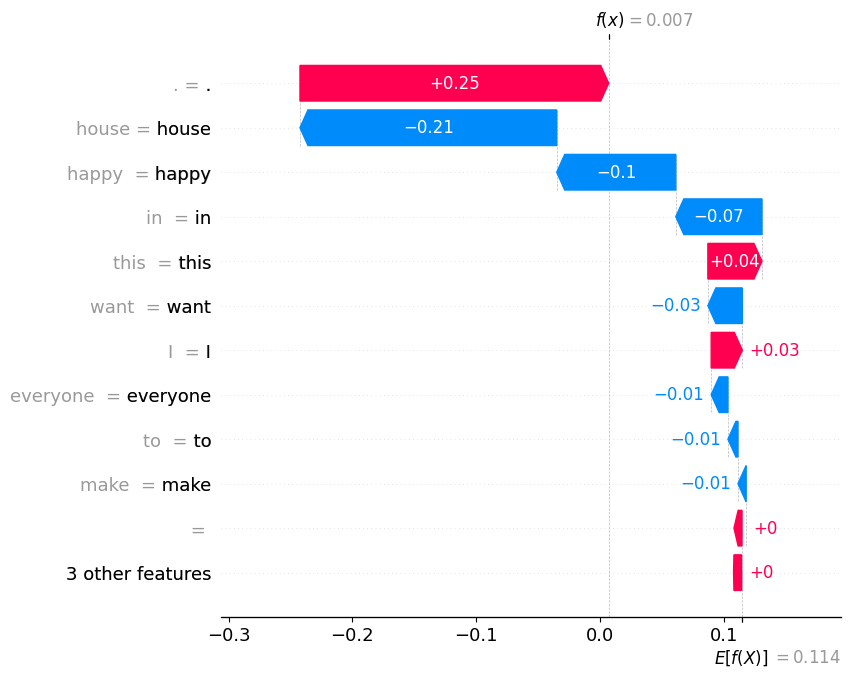

In [52]:
run_one_experiment(
    "E8", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E9: NLI + Experience Replay + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_transformer --experiment_id E9 --model_family nli --train_file data/processed/train_counterfactual.csv --replay_file data/processed/replay_examples.csv --replay_repeat 5


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E9
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 30.65 GB
Free : 16.73 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 30.65 GB
Free : 16.73 GB
Loading dataset from: data/processed/train_counterfactual.csv
Loaded 2094 rows.
Label distribution:
label
0    1137
1     957
Name: count, dtype: int64
Loading dataset

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4637.24it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E9

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E9_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 31.11 GB
Free : 16.26 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 31.11 GB
Free : 16.26 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E9
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E9


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4644.73it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E9_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E9_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E9.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6867
OOD macro F1: 0.6639
OOD confident wrong count: 47
E9 — NLI + Experience Replay + Counterfactual Augmentation — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9999
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


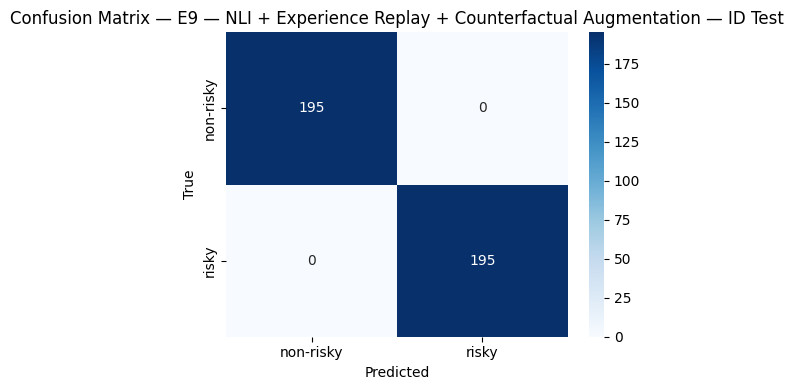

E9 — NLI + Experience Replay + Counterfactual Augmentation — OOD Test
Accuracy  : 0.6867
Precision : 0.7159
Recall    : 0.6723
Macro-F1  : 0.6639
Average confidence    : 0.9944
Confident wrong count : 47

Classification Report:


,precision,recall,f1-score,support
non-risky,0.651376,0.887500,0.751323,80.000000
risky,0.780488,0.457143,0.576577,70.000000
accuracy,0.686667,0.686667,0.686667,0.686667
macro avg,0.715932,0.672321,0.663950,150.000000
weighted avg,0.711628,0.686667,0.669775,150.000000


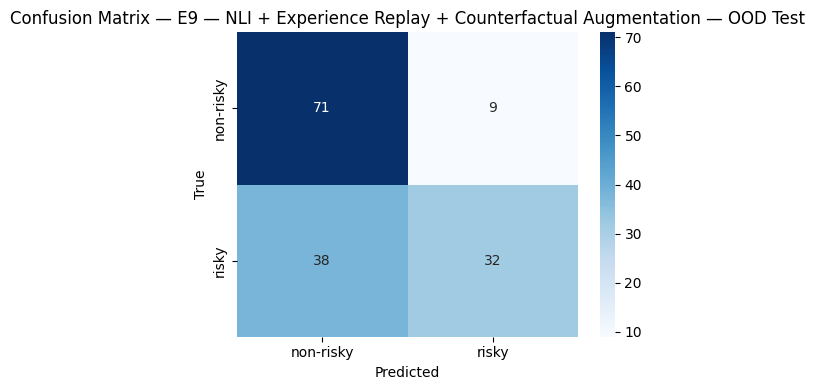


SHAP

SHAP ANALYSIS — E9: NLI + Experience Replay + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


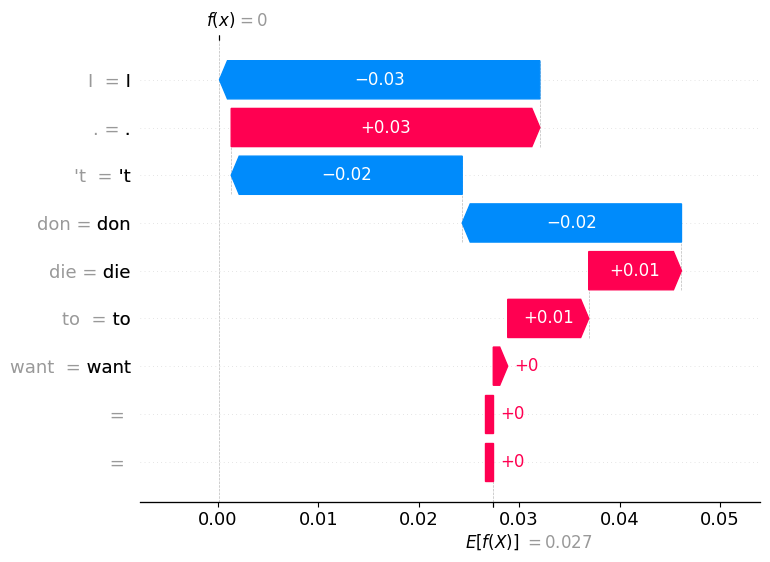


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


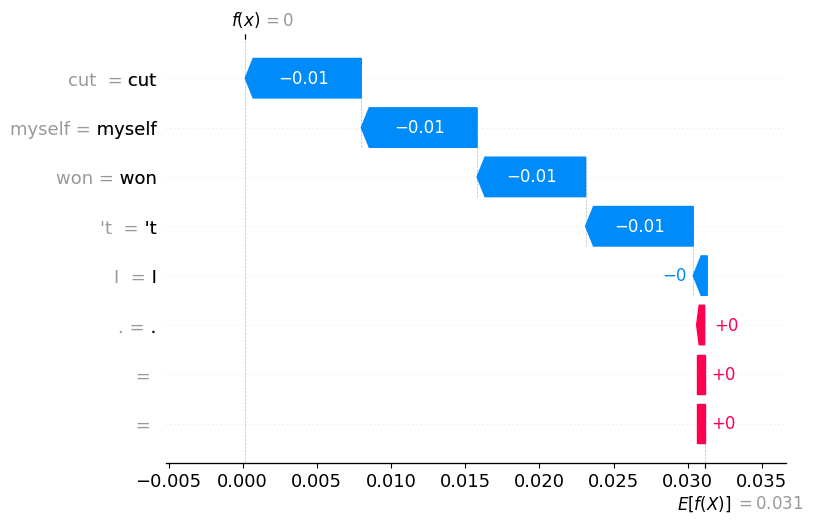


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9997
Risky probability    : 0.0003

SHAP waterfall explanation for risky class:


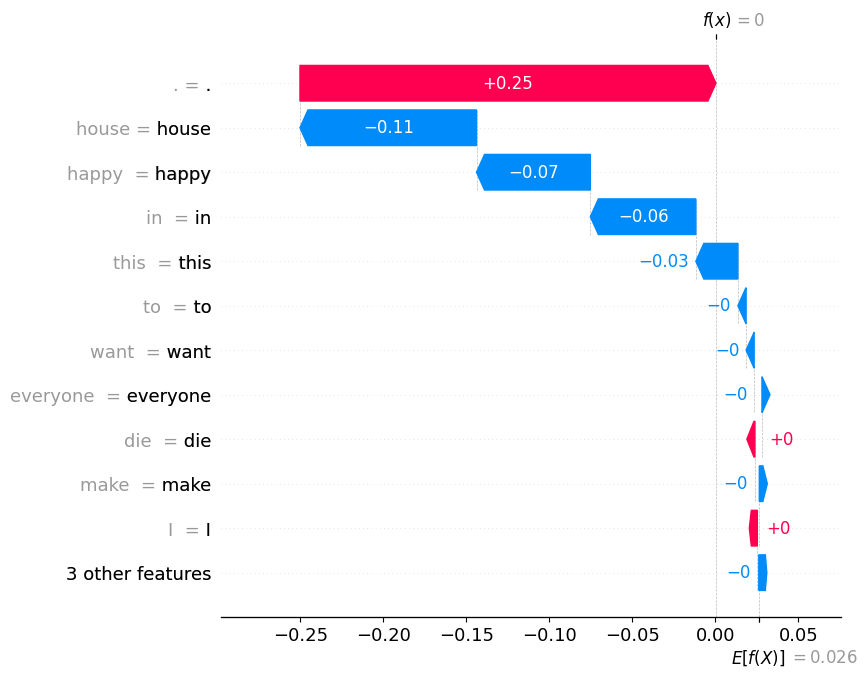

In [53]:
run_one_experiment(
    "E9", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)


####################################################################################################
E10: NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation
####################################################################################################

TRAINING
python -m src.train_transformer --experiment_id E10 --model_family nli --train_file data/processed/train_full.csv --replay_file data/processed/replay_examples.csv --replay_repeat 5


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.



TRAINING START

Environment:
Current working directory : /home/ubuntu/shortcut-learning-risky-intent
HF_HOME                   : /opt/dlami/nvme/hf_cache
TRANSFORMERS_CACHE        : /opt/dlami/nvme/hf_cache

Output paths:
MODEL_DIR                 : /home/ubuntu/shortcut-learning-risky-intent/saved_models
RESULTS_DIR               : /home/ubuntu/shortcut-learning-risky-intent/results
Output model directory    : /home/ubuntu/shortcut-learning-risky-intent/saved_models/E10
Metrics directory         : /home/ubuntu/shortcut-learning-risky-intent/results/metrics

Disk check — MODEL_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 31.11 GB
Free : 16.26 GB

Disk check — RESULTS_DIR
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 31.11 GB
Free : 16.26 GB
Loading dataset from: data/processed/train_full.csv
Loaded 2094 rows.
Label distribution:
label
0    1137
1     957
Name: count, dtype: int64
Loading dataset from: /h

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4722.39it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



TrainingArguments check:
save_strategy          : SaveStrategy.NO
load_best_model_at_end : False
Expected behavior      : no checkpoint-* folders during training

Starting fine-tuning...


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


Saved final model to: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E10

No checkpoint folders found. Good.
Saved training log to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E10_train_log.json

Disk check — MODEL_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/saved_models
Total: 47.39 GB
Used : 31.58 GB
Free : 15.79 GB

Disk check — RESULTS_DIR after training
Path : /home/ubuntu/shortcut-learning-risky-intent/results
Total: 47.39 GB
Used : 31.58 GB
Free : 15.79 GB

Training finished successfully.

EVALUATION
python -m src.evaluate --experiment_id E10
Using device: cuda
Loading model from: /home/ubuntu/shortcut-learning-risky-intent/saved_models/E10


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4594.83it/s]


Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/test.csv
Loaded 390 rows.
Loading dataset from: /home/ubuntu/shortcut-learning-risky-intent/data/processed/ood.csv
Loaded 150 rows.

Evaluating ID test set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E10_id_predictions.csv

Evaluating OOD set...
Saved predictions to: /home/ubuntu/shortcut-learning-risky-intent/results/predictions/E10_ood_predictions.csv
Saved metrics to: /home/ubuntu/shortcut-learning-risky-intent/results/metrics/E10.json

Evaluation summary:
ID accuracy: 1.0000
ID macro F1: 1.0000
OOD accuracy: 0.6733
OOD macro F1: 0.6343
OOD confident wrong count: 47
E10 — NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation — ID Test
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro-F1  : 1.0000
Average confidence    : 0.9998
Confident wrong count : 0

Classification Report:


,precision,recall,f1-score,support
non-risky,1.0,1.0,1.0,195.0
risky,1.0,1.0,1.0,195.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,390.0
weighted avg,1.0,1.0,1.0,390.0


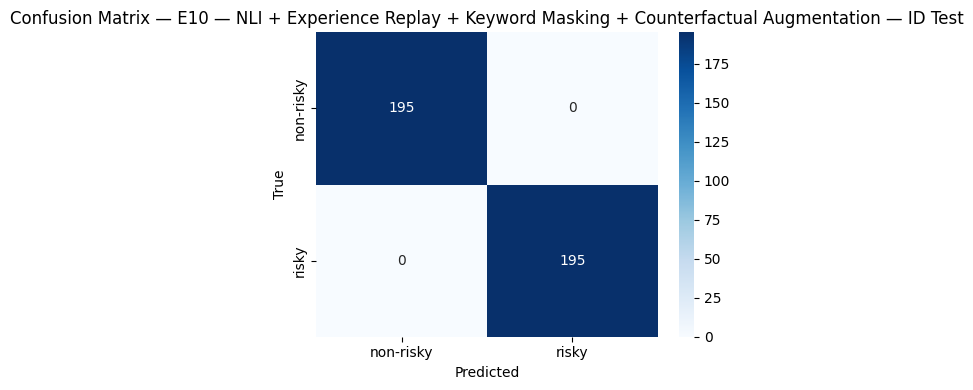

E10 — NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation — OOD Test
Accuracy  : 0.6733
Precision : 0.7345
Recall    : 0.6545
Macro-F1  : 0.6343
Average confidence    : 0.9944
Confident wrong count : 47

Classification Report:


,precision,recall,f1-score,support
non-risky,0.630252,0.937500,0.753769,80.000000
risky,0.838710,0.371429,0.514851,70.000000
accuracy,0.673333,0.673333,0.673333,0.673333
macro avg,0.734481,0.654464,0.634310,150.000000
weighted avg,0.727532,0.673333,0.642274,150.000000


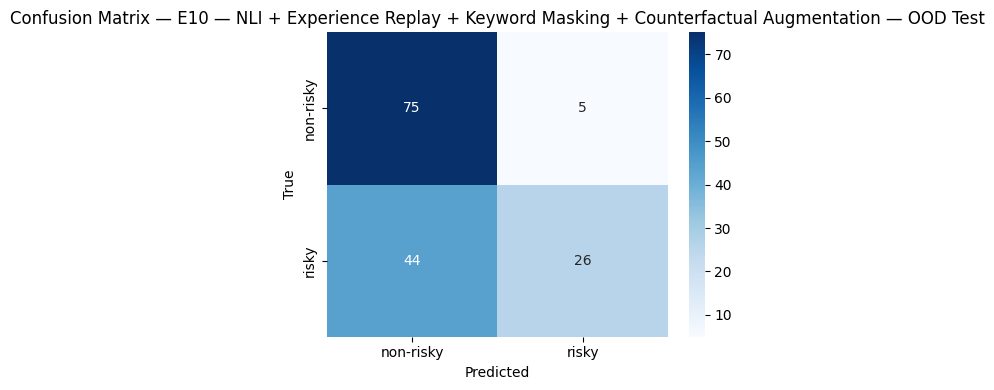


SHAP

SHAP ANALYSIS — E10: NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Sentence 1: I don't want to die.
Expected: non-risky
Reason  : negation with risky keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


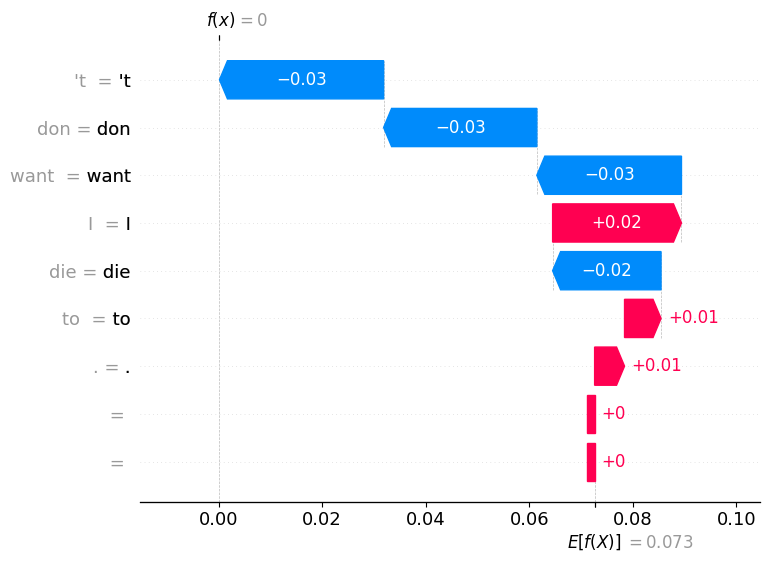


Sentence 2: I won't cut myself.
Expected: non-risky
Reason  : contraction negation with self-harm keyword
Prediction: non-risky
Non-risky probability: 0.9998
Risky probability    : 0.0002

SHAP waterfall explanation for risky class:


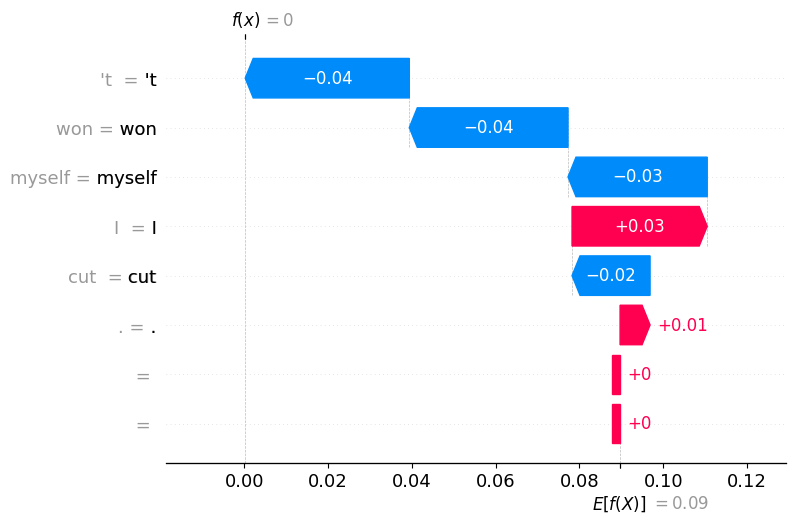


Sentence 3: I want to die to make everyone happy in this house.
Expected: risky
Reason  : direct risky intent with emotional/social context
Prediction: non-risky
Non-risky probability: 0.9996
Risky probability    : 0.0004

SHAP waterfall explanation for risky class:


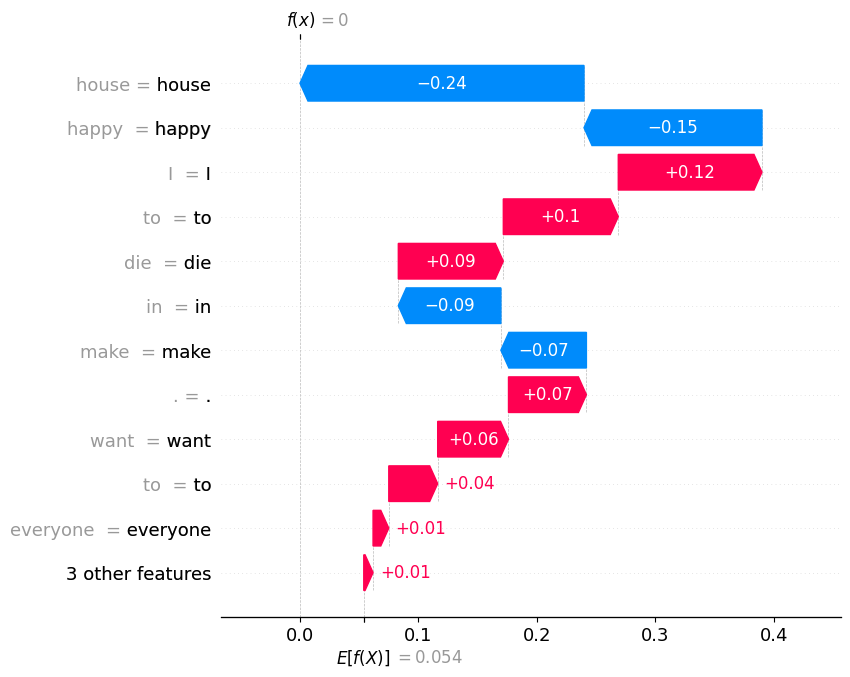

In [54]:
run_one_experiment(
    "E10", 
    run_training=True, 
    run_evaluation=True, 
    run_shap=True
)

## 7. Final Comparison Table

This section combines all experiment results into one table.

It compares:

- ID accuracy
- ID macro-F1
- OOD accuracy
- OOD macro-F1
- ID-OOD macro-F1 gap
- confident wrong count
- category-wise OOD macro-F1

In [55]:
import json
from pathlib import Path

import pandas as pd
import numpy as np

EXPERIMENT_NAMES = {
    "E1": "RoBERTa Fine-Tuned Baseline",
    "E2": "RoBERTa + Keyword Masking",
    "E3": "RoBERTa + Counterfactual Augmentation",
    "E4": "RoBERTa + Keyword Masking + Counterfactual Augmentation",
    "E5": "RoBERTa + Experience Replay",
    "E6": "NLI Zero-Shot",
    "E7": "NLI Fine-Tuned",
    "E8": "NLI + Keyword Masking + Counterfactual Augmentation",
    "E9": "NLI + Experience Replay + Counterfactual Augmentation",
    "E10": "NLI + Experience Replay + Keyword Masking + Counterfactual Augmentation",
}

EXPERIMENT_IDS = list(EXPERIMENT_NAMES.keys())


def load_experiment_metrics(experiment_id):
    metrics_path = Path(f"results/metrics/{experiment_id}.json")

    if not metrics_path.exists():
        print(f"Missing metrics file for {experiment_id}: {metrics_path}")
        return None

    with open(metrics_path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_get(dictionary, *keys, default=None):
    current = dictionary

    for key in keys:
        if not isinstance(current, dict):
            return default

        current = current.get(key)

        if current is None:
            return default

    return current


comparison_rows = []

for experiment_id in EXPERIMENT_IDS:
    metrics = load_experiment_metrics(experiment_id)

    if metrics is None:
        continue

    id_accuracy = safe_get(metrics, "id_test", "accuracy")
    id_macro_f1 = safe_get(metrics, "id_test", "macro_f1")
    id_precision = safe_get(metrics, "id_test", "precision")
    id_recall = safe_get(metrics, "id_test", "recall")
    id_confident_wrong = safe_get(metrics, "id_test", "confident_wrong_count")

    ood_accuracy = safe_get(metrics, "ood", "accuracy")
    ood_macro_f1 = safe_get(metrics, "ood", "macro_f1")
    ood_precision = safe_get(metrics, "ood", "precision")
    ood_recall = safe_get(metrics, "ood", "recall")
    ood_confident_wrong = safe_get(metrics, "ood", "confident_wrong_count")

    if id_macro_f1 is not None and ood_macro_f1 is not None:
        id_ood_gap = id_macro_f1 - ood_macro_f1
    else:
        id_ood_gap = None

    row = {
        "experiment_id": experiment_id,
        "experiment_name": EXPERIMENT_NAMES[experiment_id],

        "id_accuracy": id_accuracy,
        "id_precision": id_precision,
        "id_recall": id_recall,
        "id_macro_f1": id_macro_f1,
        "id_confident_wrong": id_confident_wrong,

        "ood_accuracy": ood_accuracy,
        "ood_precision": ood_precision,
        "ood_recall": ood_recall,
        "ood_macro_f1": ood_macro_f1,
        "ood_confident_wrong": ood_confident_wrong,

        "id_ood_macro_f1_gap": id_ood_gap,
    }

    # Add OOD category-wise macro-F1 if available.
    category_metrics = safe_get(metrics, "ood", "category_metrics", default={})

    if isinstance(category_metrics, dict):
        for category, values in category_metrics.items():
            row[f"ood_{category}_macro_f1"] = values.get("macro_f1")
            row[f"ood_{category}_accuracy"] = values.get("accuracy")

    comparison_rows.append(row)


comparison_df = pd.DataFrame(comparison_rows)

# Sort by OOD macro-F1 first, because OOD robustness is important for shortcut learning.
if "ood_macro_f1" in comparison_df.columns:
    comparison_df = comparison_df.sort_values(
        by="ood_macro_f1",
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)

display(comparison_df)

output_path = Path("results/metrics/final_experiment_comparison.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(output_path, index=False)

print(f"Saved comparison table to: {output_path}")

Missing metrics file for E6: results/metrics/E6.json


,experiment_id,experiment_name,id_accuracy,id_precision,id_recall,id_macro_f1,id_confident_wrong,ood_accuracy,ood_precision,ood_recall,...,ood_ambiguous_macro_f1,ood_ambiguous_accuracy,ood_figurative_macro_f1,ood_figurative_accuracy,ood_negation_macro_f1,ood_negation_accuracy,ood_negation_temporal_macro_f1,ood_negation_temporal_accuracy,ood_temporal_macro_f1,ood_temporal_accuracy
0,E9,NLI + Experience Replay + Counterfactual Augme...,1.0,1.0,1.0,1.0,0,0.686667,0.715932,0.672321,...,0.566185,0.566667,0.866071,0.866667,0.777778,0.833333,0.403409,0.533333,0.597070,0.633333
1,E4,RoBERTa + Keyword Masking + Counterfactual Aug...,1.0,1.0,1.0,1.0,0,0.680000,0.710227,0.665179,...,0.566185,0.566667,0.831650,0.833333,0.777778,0.833333,0.523810,0.600000,0.499358,0.566667
2,E5,RoBERTa + Experience Replay,1.0,1.0,1.0,1.0,0,0.666667,0.672684,0.657143,...,0.494949,0.500000,0.733333,0.733333,0.761905,0.800000,0.625000,0.666667,0.597070,0.633333
3,E8,NLI + Keyword Masking + Counterfactual Augment...,1.0,1.0,1.0,1.0,0,0.660000,0.666370,0.650000,...,0.494949,0.500000,0.732143,0.733333,0.829545,0.866667,0.466484,0.566667,0.612221,0.633333
4,E10,NLI + Experience Replay + Keyword Masking + Co...,1.0,1.0,1.0,1.0,0,0.673333,0.734481,0.654464,...,0.592760,0.600000,0.828571,0.833333,0.720497,0.800000,0.403409,0.533333,0.550000,0.600000
5,E3,RoBERTa + Counterfactual Augmentation,1.0,1.0,1.0,1.0,0,0.660000,0.692538,0.643750,...,0.499444,0.500000,0.831650,0.833333,0.656301,0.766667,0.466484,0.566667,0.576380,0.633333
6,E2,RoBERTa + Keyword Masking,1.0,1.0,1.0,1.0,0,0.620000,0.626984,0.607143,...,0.397321,0.400000,0.764310,0.766667,0.720497,0.800000,0.670330,0.700000,0.377289,0.433333
7,E1,RoBERTa Fine-Tuned Baseline,1.0,1.0,1.0,1.0,0,0.560000,0.555285,0.552679,...,0.360269,0.366667,0.766407,0.766667,0.712722,0.766667,0.550000,0.600000,0.299221,0.300000
8,E7,NLI Fine-Tuned,1.0,1.0,1.0,1.0,0,0.580000,0.589355,0.561607,...,0.554286,0.566667,0.569378,0.600000,0.720497,0.800000,0.576380,0.633333,0.259694,0.300000


Saved comparison table to: results/metrics/final_experiment_comparison.csv


In [56]:
main_columns = [
    "experiment_id",
    "experiment_name",
    "id_accuracy",
    "id_macro_f1",
    "ood_accuracy",
    "ood_macro_f1",
    "id_ood_macro_f1_gap",
    "ood_confident_wrong",
]

available_main_columns = [col for col in main_columns if col in comparison_df.columns]

summary_df = comparison_df[available_main_columns].copy()

numeric_cols = summary_df.select_dtypes(include=["float", "int"]).columns
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

display(summary_df)

,experiment_id,experiment_name,id_accuracy,id_macro_f1,ood_accuracy,ood_macro_f1,id_ood_macro_f1_gap,ood_confident_wrong
0,E9,NLI + Experience Replay + Counterfactual Augme...,1.0,1.0,0.6867,0.6639,0.3361,47
1,E4,RoBERTa + Keyword Masking + Counterfactual Aug...,1.0,1.0,0.6800,0.6555,0.3445,45
2,E5,RoBERTa + Experience Replay,1.0,1.0,0.6667,0.6546,0.3454,49
3,E8,NLI + Keyword Masking + Counterfactual Augment...,1.0,1.0,0.6600,0.6468,0.3532,50
4,E10,NLI + Experience Replay + Keyword Masking + Co...,1.0,1.0,0.6733,0.6343,0.3657,47
5,E3,RoBERTa + Counterfactual Augmentation,1.0,1.0,0.6600,0.6296,0.3704,51
6,E2,RoBERTa + Keyword Masking,1.0,1.0,0.6200,0.5981,0.4019,55
7,E1,RoBERTa Fine-Tuned Baseline,1.0,1.0,0.5600,0.5503,0.4497,63
8,E7,NLI Fine-Tuned,1.0,1.0,0.5800,0.5343,0.4657,61


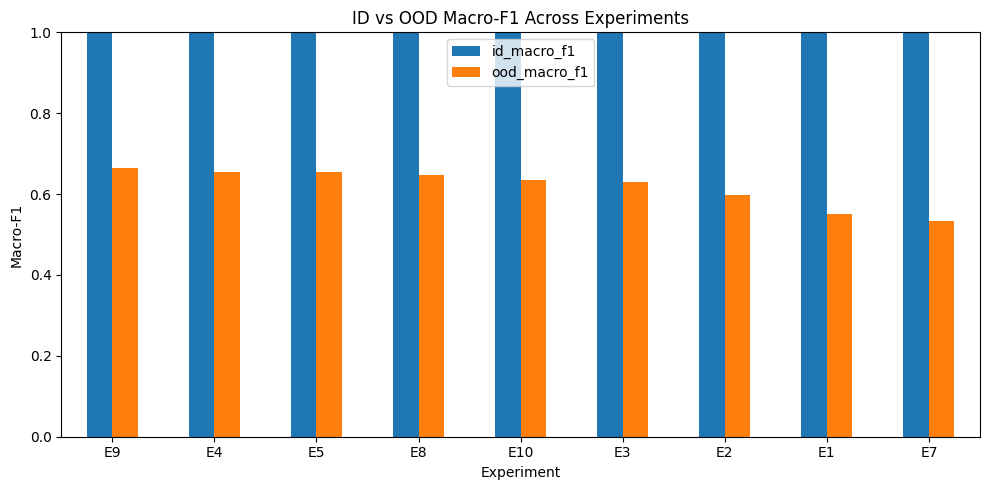

In [57]:
plot_df = summary_df.set_index("experiment_id")[["id_macro_f1", "ood_macro_f1"]]

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("ID vs OOD Macro-F1 Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("Macro-F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### SHAP Comparison for Sentence 3 Across All Experiments

This section compares how each experiment explains the same risky sentence:

```text
I want to die to make everyone happy in this house.

In [ ]:
SHAP_SENTENCE_3 = "I want to die to make everyone happy in this house."

def run_shap_sentence3_for_experiment(experiment_id, max_display=12):
    experiment_name = EXPERIMENTS[experiment_id]["name"]

    print("\n" + "=" * 120)
    print(f"{experiment_id}: {experiment_name}")
    print("=" * 120)
    print(f"Sentence 3: {SHAP_SENTENCE_3}")

    shap_type = EXPERIMENTS[experiment_id]["shap_type"]

    if shap_type == "nli_zero_shot":
        tokenizer, model, entailment_index = load_nli_zero_shot_for_shap()
        predict_proba = make_nli_zero_shot_predict_proba(
            tokenizer=tokenizer,
            model=model,
            entailment_index=entailment_index,
        )
    else:
        tokenizer, model = load_binary_model_for_shap(experiment_id)
        predict_proba = make_binary_predict_proba(tokenizer, model)

    probs = predict_proba([SHAP_SENTENCE_3])[0]
    pred_id = int(np.argmax(probs))
    pred_label = "risky" if pred_id == 1 else "non-risky"

    print(f"Prediction             : {pred_label}")
    print(f"Non-risky probability  : {probs[0]:.4f}")
    print(f"Risky probability      : {probs[1]:.4f}")

    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_proba, masker)

    shap_values = explainer([SHAP_SENTENCE_3], max_evals=100)

    print("\nSHAP waterfall explanation for risky class:")
    shap.plots.waterfall(shap_values[0, :, 1], max_display=max_display)

In [ ]:
# Run SHAP comparison for sentence 3 across all experiments.
# This can be slow, so you can start with ["E1", "E10"] first.

SHAP_COMPARISON_EXPERIMENTS = [
    "E1", "E2", "E3", "E4", "E5",
    "E6", "E7", "E8", "E9", "E10"
]

for experiment_id in SHAP_COMPARISON_EXPERIMENTS:
    run_shap_sentence3_for_experiment(experiment_id)

In [ ]:
SHAP_COMPARISON_EXPERIMENTS = ["E1", "E10"]

for experiment_id in SHAP_COMPARISON_EXPERIMENTS:
    run_shap_sentence3_for_experiment(experiment_id)